In [1]:
import pickle
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from collections import Counter
import glob
import ast
import csv
import ast
import json
import requests
import random
from decimal import Decimal

In [2]:
# define functions

def todata(dict1, dict2, val_type = 'MEAN'):
    valid_keys = list(dict1.keys() & dict2.keys())
    data1 = [dict1[x] for x in valid_keys]
    data2 = [dict2[x] for x in valid_keys]
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
        
    if type(data2[0]) == dict:
        data2 = [x[val_type] for x in data2]
    
    return valid_keys, data1, data2

def scatter(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(data1, data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def loglog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), np.log10(data2), marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def xlog(dict1, dict2, x_axis = 'x-axis', y_axis = 'y-axis'):
    valid_keys, data1, data2 = todata(dict1, dict2)
    plt.scatter(np.log10(data1), data2, marker='o', color='b', alpha = 0.1, label='Data Points', zorder=2)
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def histogram(dict1, val_type = 'MEAN', bins = 10, x_axis = 'x-axis', y_axis ='counts'):
    data1 = list(dict1.values())
    
    if type(data1[0]) == dict:
        data1 = [x[val_type] for x in data1]
    
    plt.hist(data1, bins=bins, edgecolor='k')
    plt.xlabel(x_axis)
    plt.ylabel(y_axis)
    plt.show()

def dict2csv(my_dict, csv_file_path):
    with open(csv_file_path, 'w', newline='') as csv_file:
        csv_writer = csv.writer(csv_file)
        for key, value in my_dict.items():
            csv_writer.writerow([key] + [value])

def csv2dict(csv_file_path):
    result_dict = {}
    with open(csv_file_path, 'r') as csv_file:
        csv_reader = csv.reader(csv_file)
        
        for row in csv_reader:
            try:
                result_dict[row[0]] = ast.literal_eval(row[1])  # value is list
            except:
                result_dict[row[0]] = row[1]
                
    return result_dict

def rnWith(xgroup, rn2rules, rn2cpds):
    rnWithX = []
    for reaction, rules in rn2rules.items():
        if reaction in rn2cpds:  # only get rns that show up in SI (12872 -> 8558)
            for rule in rules:
                if xgroup in rule:
                    rnWithX.append(reaction)
                    break
    return rnWithX


class EcodDomain:
    """Class for working with ECOD domains."""

    def __init__(self, ecod_line):
        self.uid = ecod_line.split('\t')[0]
        self.ecod_domain_id = ecod_line.split('\t')[1]
        self.f_id = ecod_line.split('\t')[3]
        self.pdb = ecod_line.split('\t')[4]
        self.chain = ecod_line.split('\t')[5]
        #self.pdb_range = self.parse_ecod_range(ecod_line.split('\t')[6])
        self.seqid_range = ecod_line.split('\t')[7]
        self.arch_name = ecod_line.split('\t')[9]
        self.x_name = ecod_line.split('\t')[10]
        self.h_name = ecod_line.split('\t')[11]
        self.t_name = ecod_line.split('\t')[12]
        self.f_name = ecod_line.split('\t')[13]
        self.asm_status = ecod_line.split('\t')[14]
        self.ligand = ecod_line.split('\t')[15].replace('NO_LIGANDS_4A',
                                                        '').split(',')

In [3]:
rn2cpds = csv2dict('../data/assets/rn2cpds_SI.csv')
rn2rev = csv2dict('../data/assets/rn2reversible.csv')
rn2eqn = csv2dict('../data/assets/rn2eqn_SI.csv')
rn2rules = pd.read_pickle('../data/assets/rn2rules.20230224.pkl')
rn2modules = csv2dict('../data/assets/rn2modules.csv')
rn2def = csv2dict('../data/assets/rn2def_complete.csv')
rn2name = csv2dict('../data/assets/rn2name.csv')

map2name = csv2dict('../data/assets/map2name.csv')
map2rns = csv2dict('../data/assets/map2rns.csv')
module2name = csv2dict('../data/assets/module2name.csv')
module2rns = csv2dict('../data/assets/module2rns.csv')

# Get the KEGG pathway associated with the biosynthesis of every AA:

In [4]:
"""
From KEGG website (b)
14 maps:

00250 M   Alanine, aspartate and glutamate metabolism
00260 M N Glycine, serine and threonine metabolism
00270 M N Cysteine and methionine metabolism
00280 M N Valine, leucine and isoleucine degradation
00290 M   Valine, leucine and isoleucine biosynthesis
00300 M   Lysine biosynthesis
00310 M N Lysine degradation
00220 M N Arginine biosynthesis
00330 M N Arginine and proline metabolism
00340 M N Histidine metabolism
00350 M N Tyrosine metabolism
00360 M   Phenylalanine metabolism
00380 M N Tryptophan metabolism
00400 M N Phenylalanine, tyrosine and tryptophan biosynthesis
"""

# ADENQ, GST, CM, VLI, K, (R), RP, H, Y, F, W, (FYW) => 20 AAs

'\nFrom KEGG website (b)\n14 maps:\n\n00250 M   Alanine, aspartate and glutamate metabolism\n00260 M N Glycine, serine and threonine metabolism\n00270 M N Cysteine and methionine metabolism\n00280 M N Valine, leucine and isoleucine degradation\n00290 M   Valine, leucine and isoleucine biosynthesis\n00300 M   Lysine biosynthesis\n00310 M N Lysine degradation\n00220 M N Arginine biosynthesis\n00330 M N Arginine and proline metabolism\n00340 M N Histidine metabolism\n00350 M N Tyrosine metabolism\n00360 M   Phenylalanine metabolism\n00380 M N Tryptophan metabolism\n00400 M N Phenylalanine, tyrosine and tryptophan biosynthesis\n'

In [5]:
AAmaps = []
aa_names = ['Proline', 'Alanine', 'Valine', 'Isoleucine', 'Leucine', 'Aspartate', 'Aspartic acid', 'Glutamate', 'Glutamic acid', 'Asparagine', 'Glutamine', 'Serine', 'Threonine', 'Tryptophan', 'Tyrosine', 'Phenylalanine', 'Methionine', 'Cysteine', 'Glycine', 'Histidine', 'Lysine', 'Arginine']
for name in aa_names:
    for m, value in map2name.items():
        if name in value:
            print(m, value)
            AAmaps.append(m)

map00250 Alanine, aspartate and glutamate metabolism
map00410 beta-Alanine metabolism
map00280 Valine, leucine and isoleucine degradation
map00290 Valine, leucine and isoleucine biosynthesis
map04724 Glutamatergic synapse
map00380 Tryptophan metabolism
map00350 Tyrosine metabolism
map00360 Phenylalanine metabolism
map00400 Phenylalanine, tyrosine and tryptophan biosynthesis
map00270 Cysteine and methionine metabolism
map00260 Glycine, serine and threonine metabolism
map00340 Histidine metabolism
map00300 Lysine biosynthesis
map00310 Lysine degradation
map00220 Arginine biosynthesis
map00330 Arginine and proline metabolism


In [6]:
print(len(AAmaps))

# ignoring beta-Alanine metabolism and Glutamatergic synapse, it's 14 maps
AAmaps.remove('map00410')
AAmaps.remove('map04724')
print(len(AAmaps))

16
14


In [7]:
# modules
AAmodules = []
aa_names = ['Proline', 'Alanine', 'Valine', 'Isoleucine', 'Leucine', 'Aspartate', 'Aspartic acid', 'Glutamate', 'Glutamic acid', 'Asparagine', 'Glutamine', 'Serine', 'Threonine', 'Tryptophan', 'Tyrosine', 'Phenylalanine', 'Methionine', 'Cysteine', 'Glycine', 'Histidine', 'Lysine', 'Arginine']
for name in aa_names:
    for mod, value in module2name.items():
        if name in value:
            print(mod, value)
            AAmodules.append(mod)

M00015 Proline biosynthesis, glutamate => proline
M00970 Proline degradation, proline => glutamate
M00972 Proline metabolism
M00019 Valine/isoleucine biosynthesis, pyruvate => valine / 2-oxobutanoate => isoleucine
M00535 Isoleucine biosynthesis, pyruvate => 2-oxobutanoate
M00570 Isoleucine biosynthesis, threonine => 2-oxobutanoate => isoleucine
M00036 Leucine degradation, leucine => acetoacetate + acetyl-CoA
M00432 Leucine biosynthesis, 2-oxoisovalerate => 2-oxoisocaproate
M00020 Serine biosynthesis, glycerate-3P => serine
M00018 Threonine biosynthesis, aspartate => homoserine => threonine
M00023 Tryptophan biosynthesis, chorismate => tryptophan
M00038 Tryptophan metabolism, tryptophan => kynurenine => 2-aminomuconate
M00025 Tyrosine biosynthesis, chorismate => HPP => tyrosine
M00040 Tyrosine biosynthesis, chorismate => arogenate => tyrosine
M00044 Tyrosine degradation, tyrosine => homogentisate
M00024 Phenylalanine biosynthesis, chorismate => phenylpyruvate => phenylalanine
M00910 Phe

In [8]:
len(AAmodules)

41

In [9]:
# biosynth. module exists for 15 AAs: PVILS TWYFM C(G)HKR

# for ADENQ:
# map00250 Alanine, aspartate and glutamate metabolism

# larger map exists for all of AA metabolism:
# map01230 Biosynthesis of amino acids

# Table:
Amino acid Pathway, KEGG rid, KO Group, Fold Rules, KEGG Module(s), Reaction in words 

In [10]:
# rn2ko from Harrison's github repo: https://github.com/hbsmith/rn2ko/tree/main/mapping
rn2ko = pd.read_pickle('../data/assets/rn2ko_map_combined.pkl')

In [11]:
rn2def['R00093']

'2 L-Glutamate + NAD+ <=> L-Glutamine + 2-Oxoglutarate + NADH + H+'

In [12]:
rn2name['R00093']

'L-glutamate:NAD+ oxidoreductase (transaminating)'

In [13]:
# test:

for rn in map2rns['map00250']:
    print(rn, rn2ko.get(rn, 'N/A'), rn2rules.get(rn, 'N/A'), rn2modules.get(rn, 'N/A'), rn2def[rn])

R00093 {frozenset({'K00264'})} {frozenset({'187', '207', '2003', '2002', '210', '304'})} N/A 2 L-Glutamate + NAD+ <=> L-Glutamine + 2-Oxoglutarate + NADH + H+
R00114 {frozenset({'K00265', 'K00266'})} {frozenset({'187', '207', '2003', '2002', '210', '304'})} N/A 2 L-Glutamate + NADP+ <=> L-Glutamine + 2-Oxoglutarate + NADPH + H+
R00149 {frozenset({'K01948'})} {frozenset({'2007', '2003', '206', '2487', '101', '7543'})} ['M00029'] 2 ATP + Ammonia + CO2 + H2O <=> 2 ADP + Orthophosphate + Carbamoyl phosphate
R00243 {frozenset({'K15371'}), frozenset({'K00261'}), frozenset({'K00260'})} {frozenset({'2003'}), frozenset({'2007', '2003'})} N/A L-Glutamate + NAD+ + H2O <=> 2-Oxoglutarate + Ammonia + NADH + H+
R00248 {frozenset({'K00262'}), frozenset({'K00261'}), frozenset({'K00265', 'K00266'})} {frozenset({'187', '207', '2003', '2002', '210', '304'}), frozenset({'2007', '2003'})} ['M00740'] L-Glutamate + NADP+ + H2O <=> 2-Oxoglutarate + Ammonia + NADPH + H+
R00253 {frozenset({'K01915'})} {frozense

In [14]:
for m in AAmaps:
    print(m, map2name[m], len(map2rns[m]))

map00250 Alanine, aspartate and glutamate metabolism 47
map00280 Valine, leucine and isoleucine degradation 51
map00290 Valine, leucine and isoleucine biosynthesis 25
map00380 Tryptophan metabolism 104
map00350 Tyrosine metabolism 111
map00360 Phenylalanine metabolism 64
map00400 Phenylalanine, tyrosine and tryptophan biosynthesis 49
map00270 Cysteine and methionine metabolism 103
map00260 Glycine, serine and threonine metabolism 75
map00340 Histidine metabolism 53
map00300 Lysine biosynthesis 39
map00310 Lysine degradation 72
map00220 Arginine biosynthesis 31
map00330 Arginine and proline metabolism 101


In [15]:
# Collecting the data
data = []
for m in AAmaps:
    for rn in map2rns[m]:
        data.append({
            'map': f'{m}',
            'reaction': rn,
            'KOs': rn2ko.get(rn, 'N/A'),
            'Rules': rn2rules.get(rn, 'N/A'),
            'Modules': rn2modules.get(rn, 'N/A'),
            'Definition': rn2def[rn]
        })

df = pd.DataFrame(data)
df

,map,reaction,KOs,Rules,Modules,Definition
0,map00250,R00093,{(K00264)},"{(187, 207, 2003, 2002, 210, 304)}",N/A,2 L-Glutamate + NAD+ <=> L-Glutamine + 2-Oxogl...
1,map00250,R00114,"{(K00265, K00266)}","{(187, 207, 2003, 2002, 210, 304)}",N/A,2 L-Glutamate + NADP+ <=> L-Glutamine + 2-Oxog...
2,map00250,R00149,{(K01948)},"{(2007, 2003, 206, 2487, 101, 7543)}",[M00029],2 ATP + Ammonia + CO2 + H2O <=> 2 ADP + Orthop...
3,map00250,R00243,"{(K15371), (K00261), (K00260)}","{(2003), (2007, 2003)}",N/A,L-Glutamate + NAD+ + H2O <=> 2-Oxoglutarate + ...
4,map00250,R00248,"{(K00262), (K00261), (K00265, K00266)}","{(187, 207, 2003, 2002, 210, 304), (2007, 2003)}",[M00740],L-Glutamate + NADP+ + H2O <=> 2-Oxoglutarate +...
...,...,...,...,...,...,...
920,map00330,R11819,{(K23121)},N/A,N/A,Hydroxyproline <=> (S)-1-Pyrroline-5-carboxyla...
921,map00330,R12085,{(K22842)},{(213)},N/A,Acetyl-CoA + L-Glutamate 5-semialdehyde <=> Co...
922,map00330,R12706,"{(K24952, K24953)}",N/A,N/A,Nopaline + H2O + Acceptor <=> L-Arginine + 2-O...
923,map00330,R12707,"{(K24954, K24955)}",N/A,N/A,Octopine + H2O + Acceptor <=> L-Arginine + Pyr...


In [16]:
# df.to_csv('amino_acid_pathways_folds.csv')

In [17]:
len(set(df['reaction']))  # 867 unique reactions

867

### get pdb2xgroup for verification

In [18]:
path = '../data/ecod.develop279.domains.txt'

In [19]:
pdb2xgroup = {}

with open(path, 'r') as file:
    lines = file.readlines()

    for line in lines:
        if line[0] == '#':
            continue

        try:
            domain = EcodDomain(line)
            xgroup = domain.f_id.split('.')[0]
            pdb = domain.pdb

            if pdb not in pdb2xgroup:
                pdb2xgroup[pdb] = [xgroup]
            else:
                pdb2xgroup[pdb].append(xgroup)
        except:
            print(line)

002709051	e6lhjA2	AUTO_NONREP	





1.1	6lhj	A	A:1-231	A:1-231	NO_UNP	a/b three-layered sandwiches	"NO_X_NAME"	"NO_H_NAME"	"Dihydrofolate reductases"	F_UNCLASSIFIED	NOT_DOMAIN_ASSEMBLY	NO_LIGANDS_4A

002708863	e6levB2	AUTO_NONREP	





1.1	6lev	B	B:4-230	B:4-230	NO_UNP	a/b three-layered sandwiches	"NO_X_NAME"	"NO_H_NAME"	"Dihydrofolate reductases"	F_UNCLASSIFIED	NOT_DOMAIN_ASSEMBLY	NO_LIGANDS_4A



In [20]:
# give me rows containing the reaction
r = 'R00732'
print(df[df.isin([r]).any(axis=1)])

          map reaction                   KOs                      Rules  \
409  map00400   R00732  {(K24018), (K00220)}  {(328, 129), (2003, 129)}   

      Modules                                         Definition  
409  [M00040]  L-Arogenate + NAD+ <=> L-Tyrosine + CO2 + NADH...  


In [21]:
df.loc[409]

map                                                    map00400
reaction                                                 R00732
KOs                                        {(K24018), (K00220)}
Rules                                 {(328, 129), (2003, 129)}
Modules                                                [M00040]
Definition    L-Arogenate + NAD+ <=> L-Tyrosine + CO2 + NADH...
Name: 409, dtype: object

In [22]:
set(pdb2xgroup['4wji'])

{'129', '2003'}

In [23]:
# code to increase width of jupyter notebook cell (to see complete picture)

# from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))

In [24]:
# add information about manual verification

rn2verification = {}

rn2verification['R00149'] = "K01948, carbamoyl-phosphate synthase, 1t36, {'101', '2003', '2007', '206', '2487', '7543'}, 6/6"
rn2verification['R00253'] = "K01915, 6.3.1.2, 2bvc, {'239', '321'}, 2/2"
rn2verification['R10688'] = "K14592, glutamate carboxypeptidase II, 2jbk, {'2011', '2487', '611'}, 3/3"
rn2verification['R01357'] = "K01907, acetoacetyl-CoA synthetase, 4wd1, {'327', '4011', '7584'}, 3/3"
rn2verification['R02661'] = "K11410, acdH, 4y9j, {'4033', '4052', '633'}, 3/3"
rn2verification['R02765'] = "K05606, 5.1.99.1, 1jc5, {'211'}, 1/1"
rn2verification['R01090'] = "K00826, 2.6.1.42, 1iyd, {'4020', '4045'}, 2/2"
rn2verification['R04094'] = "K01237, 3.2.1.147, 1myr, {'2002'}, 1/1"
rn2verification['R04323'] = "K03392, aminocarboxymuconate-semialdehyde decarboxylase, 2wm1, {'2002'}, 1/1"
rn2verification['R02532'] = "K00274, MAO (monoamine oxidase), 2vvl, {'2003', '244'}, 2/2"
rn2verification['R00689'] = "K03334, 1.4.3.2, 1f8r, {'2003', '244'}, 2/2"
rn2verification['R00694'] = "K00832, 2.6.1.57, 1ay4, {'3016', '7577'}, 2/2"
rn2verification['R02722'] = "K01694, 4.2.1.20, 1a50, {'2002', '2003'}, 2/2"
rn2verification['R00178'] = "K01611, 4.1.1.50, 1vr7, {'331'}, 1/1"
rn2verification['R09254'] = "K05821, aromatic amino acid aminotransferase II, 4je5, {'3016', '7577'}, 2/2"
rn2verification['R01826'] = "K01626, 3-deoxy-7-phosphoheptulonate synthase, 1gg1, {'2002'}, 1/1; K13853, aroG, 5ckx, {'164', '2002'}, 2/2; K01626, 3-deoxy-7-phosphoheptulonate synthase, 1rzm, {'304', '2002'}, 2/2"
rn2verification['R01388'] = "K22982, hydroxypyruvate reductase, 2gcg, {'2003'}, 1/1"
rn2verification['R06977'] = "K00836, ectB, 6rl5, {'3016', '7577'}, 2/2"
rn2verification['R04674'] = "K00274, MAO (monoamine oxidase), 2vvl, {'2003', '244'}, 2/2; K11182, diamine oxidase, 3hii, {'12', '243'}, 2/2"
rn2verification['R01934'] = "K17753, homoisocitrate dehydrogenase, 3ty3, {7510}, 1/1"
rn2verification['R07618'] = "K00382, dihydrolipoyl dehydrogenase, 1zy8, {'244', '147', '2003'}, 3/3"
rn2verification['R00258'] = "K00814, alanine transaminase, 2huu, {'3016', '7577'}, 2/2"
rn2verification['R01248'] = "K00286, pyrroline-5-carboxylate reductase, 2gra, {'129', '2003'}, 2/2"
rn2verification['R12085'] = "K22842, MPR1, 3w6x, {'213'}, 1/1"

# unresolved?
rn2verification['R00732'] = "K00220, cyclohexadienyl dehydrogenase, 4wji, {'129', '2003'}, 2/2; K24018, 2.5.1.19, 1g6t, {'328'}, 1/2"
rn2verification['R00782'] = "K01758, cystathionine gamma-lyase, 1gc2, {'3016', '7577'}, 2/2; {'7577'} not found"
rn2verification['R00565'] = "K00613, glycine amidinotransferase, 5jdw, {'232'}, 1/2"
rn2verification['R02144'] = "K22437, carnosine N-methyltransferase, 5x62, {'2003'} 1/1; {'2003', '2004'} not found"
rn2verification['R04390'] = "K00143, Lys2, 4d4g, {'4011', '7584', '327'}, 3/4"
rn2verification['R00716'] = "K14157, alpha-aminoadipic semialdehyde synthase, 5o1p, {'2003', '298'}, 2/3"

In [25]:
# # automation (read ncbi search result .txt file)

# ko = "K24018"
# text = f"/Users/tseamuscorlett/Downloads/structure_result_{ko}.txt"

# pdb_ids = []
# with open(text, 'r') as file:
#     lines = file.readlines()
#     for line in lines:
#         if 'PDB ID' in line:
#             pdb_ids.append(line.strip().split()[-1])
            
# for p in pdb_ids:
#     p = p.lower()
#     print(p, set(pdb2xgroup.get(p, "0")))

In [26]:
# # automation2 (read result file from pdb with direct sequence search)

# ko = "K24955"
# text = f"/Users/tseamuscorlett/Downloads/rcsb_pdb_ids_{ko}.txt"

# pdb_ids = []
# with open(text, 'r') as file:
#     line = file.readlines()
#     ids = line[0].split(',')
#     for i in ids:
#         pdb_ids.append(i[:4].lower())
            
# for p in pdb_ids:
#     p = p.lower()
#     print(p, set(pdb2xgroup.get(p, "0")))
#     if set(pdb2xgroup.get(p, "0")) == set(['4011', '7584', '2003', '327']):
#         print(True)

In [27]:
# add verification column to dataframe

data = []
for m in AAmaps:
    for rn in map2rns[m]:
        data.append({
            'map': f'{m}',
            'reaction': rn,
            'KOs': rn2ko.get(rn, 'N/A'),
            'Rules': rn2rules.get(rn, 'N/A'),
            'Modules': rn2modules.get(rn, 'N/A'),
            'Definition': rn2def[rn],
            'Verification': rn2verification.get(rn, 'N/A')
        })

df = pd.DataFrame(data)
df

,map,reaction,KOs,Rules,Modules,Definition,Verification
0,map00250,R00093,{(K00264)},"{(187, 207, 2003, 2002, 210, 304)}",N/A,2 L-Glutamate + NAD+ <=> L-Glutamine + 2-Oxogl...,N/A
1,map00250,R00114,"{(K00265, K00266)}","{(187, 207, 2003, 2002, 210, 304)}",N/A,2 L-Glutamate + NADP+ <=> L-Glutamine + 2-Oxog...,N/A
2,map00250,R00149,{(K01948)},"{(2007, 2003, 206, 2487, 101, 7543)}",[M00029],2 ATP + Ammonia + CO2 + H2O <=> 2 ADP + Orthop...,"K01948, carbamoyl-phosphate synthase, 1t36, {'..."
3,map00250,R00243,"{(K15371), (K00261), (K00260)}","{(2003), (2007, 2003)}",N/A,L-Glutamate + NAD+ + H2O <=> 2-Oxoglutarate + ...,N/A
4,map00250,R00248,"{(K00262), (K00261), (K00265, K00266)}","{(187, 207, 2003, 2002, 210, 304), (2007, 2003)}",[M00740],L-Glutamate + NADP+ + H2O <=> 2-Oxoglutarate +...,N/A
...,...,...,...,...,...,...,...
920,map00330,R11819,{(K23121)},N/A,N/A,Hydroxyproline <=> (S)-1-Pyrroline-5-carboxyla...,N/A
921,map00330,R12085,{(K22842)},{(213)},N/A,Acetyl-CoA + L-Glutamate 5-semialdehyde <=> Co...,"K22842, MPR1, 3w6x, {'213'}, 1/1"
922,map00330,R12706,"{(K24952, K24953)}",N/A,N/A,Nopaline + H2O + Acceptor <=> L-Arginine + 2-O...,N/A
923,map00330,R12707,"{(K24954, K24955)}",N/A,N/A,Octopine + H2O + Acceptor <=> L-Arginine + Pyr...,N/A


In [28]:
# df.to_csv('amino_acid_pathways_folds.csv')

# shuffle2

In [29]:
# import random

In [30]:
# def newRule(num_folds, new_rules):
#     new_rule = random.choices(shuffleList, k=num_folds)
    
#     # prevent duplicate folds
#     new_rule = list(set(new_rule))
#     while len(new_rule) < num_folds:
#         new_sample = random.choices(shuffleList, k=num_folds - len(new_rule))
#         new_rule.extend(new_sample)
#         new_rule = list(set(new_rule))
    
#     if frozenset(new_rule) in new_rules:  # it's a duplicate rule => run it again
#         new_rule = newRule(num_folds, new_rules)
#     return new_rule

# def shuffle2(rn2rules, shuffleList):
#     rn2rules_shuffle2 = {}
#     for rn, rules in rn2rules.items():
#         new_rules = set()
#         while len(new_rules) < len(rules):
#             for rule in rules:
#                 num_folds = len(rule)

#                 # check for impossible cases => redo the process
#                 if len(set(shuffleList)) < num_folds:
#                     print('Ran out of uniques folds! Restarting shuffle process.')
#                     return []

#                 new_rule = newRule(num_folds, new_rules)

#                 for x in new_rule:
#                     shuffleList.remove(x)
#                 new_rules.add(frozenset(new_rule))

#         rn2rules_shuffle2[rn] = new_rules
#     return rn2rules_shuffle2

In [31]:
# rn2rules_shuffle2 = {}
# while len(rn2rules_shuffle2) != len(rn2rules):
#     x2rulesNum = {}
#     for rn, rules in rn2rules.items():
#         for rule in rules:
#             for x in rule:
#                 if x not in x2rulesNum.keys():
#                     x2rulesNum[x] = 1
#                 else:
#                     x2rulesNum[x] += 1
#     shuffleList = []
#     for x in x2rulesNum:
#         for i in range(int(x2rulesNum[x])):
#             shuffleList.append(x)

#     rn2rules_shuffle2 = shuffle2(rn2rules, shuffleList)

In [32]:
# len(rn2rules_shuffle2), len(rn2rules)

### check if "all rules have same #folds" & "all reactions have same #rules"

In [33]:
# for rn, rules in rn2rules_shuffle2.items():
#     if len(rules) != len(rn2rules[rn]):
#         print('wrong number of rules!', rn, len(rules), len(rn2rules[rn]))

In [34]:
# for rn, rules in rn2rules_shuffle2.items():
#     lens = []
#     for rule in rules:
#         lens.append(len(rule))
    
#     lens_original = []
#     for rule in rn2rules[rn]:
#         lens_original.append(len(rule))
    
#     if sorted(lens) != sorted(lens_original):
#         print('wrong number of folds!', rn, lens, lens_original)

# PHGDH plot

In [35]:
# c = [0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.50]
# l = [0.130, 0.671, 1.216, 1.935, 2.329, 2.726, 3.020]
# plt.scatter(c, l)
# plt.xlabel('[NADH] (mM)')
# plt.ylabel('Absorbance')
# # plt.savefig('NADH_absorbance.png', dpi=300, bbox_inches='tight')
# plt.show()

In [36]:
# # t =[b'Time', b'T\xb0 340', b'A1', b'A2', b'A3', b'A4', b'A5', b'A6', b'A7', b'A8', b'A9', b'A10', b'A11', b'A12', b'B1', b'B2', b'B3', b'B4', b'B5', b'B6', b'B7', b'B8', b'B9', b'B10', b'B11', b'B12', b'C1', b'C2', b'C3', b'C4', b'C5', b'C6', b'C7', b'C8', b'C9', b'C10', b'C11', b'C12', b'D1', b'D2', b'D3', b'D4', b'D5', b'D6', b'D7', b'D8', b'D9', b'D10', b'D11', b'D12', b'E1', b'E2', b'E3', b'E4', b'E5', b'E6', b'E7', b'E8', b'E9', b'E10', b'E11', b'E12', b'F1', b'F2', b'F3', b'F4', b'F5', b'F6', b'F7', b'F8', b'F9', b'F10', b'F11', b'F12', b'G1', b'G2', b'G3', b'G4', b'G5', b'G6', b'G7', b'G8', b'G9', b'G10', b'G11', b'G12', b'H1', b'H2', b'H3', b'H4', b'H5', b'H6', b'H7', b'H8', b'H9', b'H10', b'H11', b'H12']
# # for item in t:
# #     print(item)


# s = [b'0:00:05', b'36.9', b
# '', b'', b'', b'', b'', b'', b'', b'', b'1.276', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.262', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.253', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.345', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.287', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.272', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.271', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'', b'1.222']
# for item in s:
#     if len(item) > 1:
#         print(item)
        
# # time, temp, A9, B9, C6, ..., H9

In [37]:
# matrix = {'time':[], 'C':[], 'D':[], 'E':[], 'F':[], 'G':[], 'H':[], 'J':[], 'blank':[], }

# file_path = '/Users/tseamuscorlett/Desktop/LongoLab/PHGDH/graphs/09July2024_new_protocol_kinetics_TC1p10.txt'
# with open(file_path, 'rb') as file:
#     lines = file.readlines()
#     datalines = lines[36:437]
#     print('time         A9        B9       C9       D9       E9       F9       G9       H9')
#     print('-------------------------------------------------------------------------------------------')
#     for line in datalines:
#         lst = line.strip().split(b'\t')
#         print(lst[0], lst[10], lst[22], lst[34], lst[46], lst[58], lst[70], lst[82], lst[94])
#         matrix['time'].append(lst[0].decode('utf-8'))
#         matrix['C'].append(float(lst[10].decode('utf-8')))
#         matrix['D'].append(float(lst[22].decode('utf-8')))
#         matrix['E'].append(float(lst[34].decode('utf-8')))
#         matrix['F'].append(float(lst[46].decode('utf-8')))
#         matrix['G'].append(float(lst[58].decode('utf-8')))
#         matrix['H'].append(float(lst[70].decode('utf-8')))
#         matrix['J'].append(float(lst[82].decode('utf-8')))
#         matrix['blank'].append(float(lst[94].decode('utf-8')))
        
# #         if line.strip().split(b'\t')[0] == ':':
# #             print(line.strip())
        

In [38]:
# for col in matrix:
#     if col != 'time':
#         delta = []
#         for v in matrix[col]:
#             delta.append(v - matrix[col][0])
#         plt.plot(delta)
# plt.xticks([])
# labels=list(matrix.keys())[1:]
# plt.legend(labels)
# plt.ylabel('∆ OD')
# plt.xlabel('time (1h)')
# # plt.savefig('09July2024_new_protocol_kinetics', dpi=300, bbox_inches='tight')
    
# plt.show()

# redox ETU

In [39]:
cpd2name = csv2dict('../data/assets/cpd2nameShort.csv')

In [40]:
# cpd2ETUfolds_perc = csv2dict('../data/assets/cpd2ETUfolds_percent_NONE.csv')
cpd2ETUfolds_perc = csv2dict('../data/assets/cpd2ETUfolds_percent_preATP.csv')

cpd2ETUfolds = {}  # no percentage cutoff
for k, vs in cpd2ETUfolds_perc.items():
    folds = set()
    for tup in vs:
        folds.add(tup[0])
    cpd2ETUfolds[k] = folds

In [41]:
redox_cpds = ['C00016', 'Z00013', 'C01352', 'C00003', 'C00004', 'C00005', 'C00006', 'C00061', 'Z00014', 'C01847']
for c in redox_cpds:
    print(c, cpd2name[c])

C00016 FAD
Z00013 FAD
C01352 FADH2
C00003 NAD+
C00004 NADH
C00005 NADPH
C00006 NADP+
C00061 FMN
Z00014 FMN
C01847 Reduced FMN


In [42]:
for c in redox_cpds:
    print(cpd2name[c], len(cpd2ETUfolds[c]), cpd2ETUfolds[c])

FAD 9 {'604', '187', '7541', '6058', '4052', '4033', '378', '278', '920'}
FAD 30 {'6058', '4052', '313', '3892', '842', '629', '3249', '7546', '4033', '3579', '1001', '604', '7507', '66', '262', '7586', '914', '3740', '278', '633', '7514', '7564', '296', '179', '187', '4294', '207', '146', '7', '3281'}
FADH2 6 {'604', '187', '6058', '4052', '4033', '278'}
NAD+ 53 {'7510', '4029', '279', '4052', '313', '7556', '6166', '7531', '3892', '276', '7501', '148', '2485', '4033', '244', '164', '920', '4004', '4335', '298', '7522', '6094', '3579', '236', '604', '66', '4002', '266', '2486', '217', '503', '159', '7586', '6096', '378', '278', '3697', '7514', '239', '237', '179', '3692', '147', '129', '3323', '4294', '270', '146', '2005', '640', '3321', '7524', '4049'}
NADH 48 {'7510', '4029', '279', '4052', '313', '7556', '7531', '6166', '3892', '276', '7501', '148', '2485', '4033', '244', '164', '4004', '4335', '298', '7522', '6094', '3579', '236', '604', '66', '4002', '266', '2486', '217', '503', 

In [43]:
# FADH2 < FAD
print(cpd2ETUfolds['C01352'] - cpd2ETUfolds['C00016'])
print(len(cpd2ETUfolds['C01352']), len(cpd2ETUfolds['C00016']))

# C_FAD has 3 folds NOT in Z_FAD
print(cpd2ETUfolds['C00016'] - cpd2ETUfolds['Z00013'])
print(len(cpd2ETUfolds['C00016']), len(cpd2ETUfolds['Z00013']))

# C_FMN has 3 folds NOT in Z_FMN
print(cpd2ETUfolds['C00061'] - cpd2ETUfolds['Z00014'])
print(len(cpd2ETUfolds['C00061']), len(cpd2ETUfolds['Z00014']))

set()
6 9
{'920', '378', '7541'}
9 30
{'920', '378', '7541'}
4 21


In [44]:
ETU_C00003 = cpd2ETUfolds['C00003']
ETU_Z00032 = cpd2ETUfolds['Z00032']
ETU_C00004 = cpd2ETUfolds['C00004']
ETU_C00005 = cpd2ETUfolds['C00005']
ETU_C00006 = cpd2ETUfolds['C00006']
ETU_C00016 = cpd2ETUfolds['C00016']
ETU_Z00013 = cpd2ETUfolds['Z00013']
ETU_C01352 = cpd2ETUfolds['C01352']
ETU_C00061 = cpd2ETUfolds['C00061']
ETU_Z00014 = cpd2ETUfolds['Z00014']
ETU_C01847 = cpd2ETUfolds['C01847']

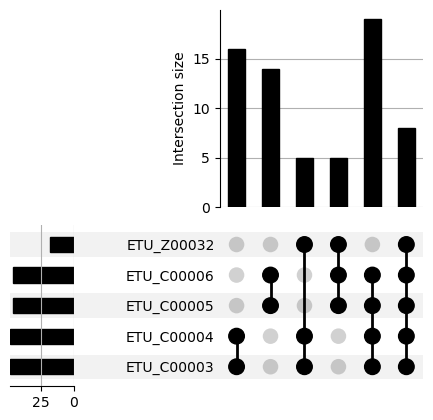

In [45]:
from upsetplot import UpSet
import warnings
# Suppress FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)

# Create a dictionary with all sets
sets = {
    'ETU_C00003': ETU_C00003,
    'ETU_Z00032': ETU_Z00032,
    'ETU_C00004': ETU_C00004,
    'ETU_C00005': ETU_C00005,
    'ETU_C00006': ETU_C00006    
}

# Generate DataFrame suitable for UpSet plot
all_elements = set.union(*sets.values())
data = {elem: [elem in sets[set_name] for set_name in sets] for elem in all_elements}

# Convert to DataFrame
df = pd.DataFrame.from_dict(data, orient='index', columns=sets.keys())

# Create a MultiIndex from boolean DataFrame
df.index = pd.MultiIndex.from_frame(df.astype(bool).reset_index(drop=True))

# Filter out self-intersections
df = df[df.sum(axis=1) > 1]

# Aggregate the data by the MultiIndex to get counts
df_counts = df.groupby(level=list(df.index.names)).size()

# Create the UpSet plot
upset = UpSet(df_counts)
upset.plot()
plt.show()

## get ECOD_domains

In [48]:
path = '../data/ecod.develop279.domains.txt'

In [49]:
x2domain_ids = {}

with open(path, 'r') as file:
    lines = file.readlines()

    for line in lines:
        if line[0] == '#':
            continue

        try:
            domain = EcodDomain(line)
            xgroup = domain.f_id.split('.')[0]
            domain_id = domain.ecod_domain_id

            if xgroup not in x2domain_ids:
                x2domain_ids[xgroup] = [domain_id]
            else:
                x2domain_ids[xgroup].append(domain_id)
        except:
            print(line)

002709051	e6lhjA2	AUTO_NONREP	





1.1	6lhj	A	A:1-231	A:1-231	NO_UNP	a/b three-layered sandwiches	"NO_X_NAME"	"NO_H_NAME"	"Dihydrofolate reductases"	F_UNCLASSIFIED	NOT_DOMAIN_ASSEMBLY	NO_LIGANDS_4A

002708863	e6levB2	AUTO_NONREP	





1.1	6lev	B	B:4-230	B:4-230	NO_UNP	a/b three-layered sandwiches	"NO_X_NAME"	"NO_H_NAME"	"Dihydrofolate reductases"	F_UNCLASSIFIED	NOT_DOMAIN_ASSEMBLY	NO_LIGANDS_4A



## make csv table

In [50]:
x_all = ETU_Z00032 | ETU_C00003 | ETU_C00004 | ETU_C00005 | ETU_C00006 | ETU_C00016 | ETU_Z00013 | ETU_C01352 | ETU_C00061 | ETU_Z00014 | ETU_C01847
len(x_all)

102

In [51]:
# C00016 FAD
# Z00013 FAD
# C01352 FADH2
# C00061 FMN
# Z00014 FMN
# C01847 Reduced FMN

# C00003 NAD+
# C00004 NADH
# C00005 NADPH
# C00006 NADP+
# Z00032 NAD/NADP

x_NAD = ETU_C00003 | ETU_C00004 | ETU_C00005 | ETU_C00006 | ETU_Z00032
x_FAD = ETU_C00016 | ETU_Z00013 | ETU_C01352 | ETU_C00061 | ETU_Z00014 | ETU_C01847
x_NAD_no_Z32 = ETU_C00003 | ETU_C00004 | ETU_C00005 | ETU_C00006

len(x_NAD), len(x_FAD), len(x_NAD_no_Z32)

(88, 41, 72)

In [52]:
data = []
for x in x_all:
    for cpd in redox_cpds:
        for tup in cpd2ETUfolds_perc[cpd]:
            if x == tup[0]:
                print(x, cpd, cpd2name[cpd], tup[1])
                data.append([x, cpd, cpd2name[cpd], tup[1]])

581 C00005 NADPH 1.0
581 C00006 NADP+ 1.0
881 Z00014 FMN 1.0
6058 C00016 FAD 1.0
6058 Z00013 FAD 1.0
6058 C01352 FADH2 1.0
6058 C00005 NADPH 1.0
6058 C00006 NADP+ 1.0
6058 Z00014 FMN 1.0
7584 C00005 NADPH 0.509
7584 C00006 NADP+ 0.509
3115 C00005 NADPH 1.0
3115 C00006 NADP+ 1.0
3654 C00005 NADPH 1.0
3654 C00006 NADP+ 1.0
6166 C00003 NAD+ 1.0
6166 C00004 NADH 1.0
6166 C00005 NADPH 1.0
6166 C00006 NADP+ 1.0
7531 C00003 NAD+ 1.0
7531 C00004 NADH 1.0
7531 C00005 NADPH 1.0
7531 C00006 NADP+ 1.0
7501 C00003 NAD+ 1.0
7501 C00004 NADH 1.0
7501 C00005 NADPH 1.0
7501 C00006 NADP+ 1.0
148 C00003 NAD+ 1.0
148 C00004 NADH 1.0
3322 C00005 NADPH 1.0
3322 C00006 NADP+ 1.0
3322 Z00014 FMN 1.0
7541 C00016 FAD 1.0
7541 C00061 FMN 1.0
2485 C00003 NAD+ 1.0
2485 C00004 NADH 1.0
3249 Z00013 FAD 1.0
3249 C00005 NADPH 1.0
3249 C00006 NADP+ 1.0
3249 Z00014 FMN 1.0
244 C00003 NAD+ 1.0
244 C00004 NADH 1.0
244 C00005 NADPH 1.0
244 C00006 NADP+ 1.0
4004 C00003 NAD+ 1.0
4004 C00004 NADH 1.0
4004 C00005 NADPH 1.0
400

In [53]:
data

[['581', 'C00005', 'NADPH', 1.0],
 ['581', 'C00006', 'NADP+', 1.0],
 ['881', 'Z00014', 'FMN', 1.0],
 ['6058', 'C00016', 'FAD', 1.0],
 ['6058', 'Z00013', 'FAD', 1.0],
 ['6058', 'C01352', 'FADH2', 1.0],
 ['6058', 'C00005', 'NADPH', 1.0],
 ['6058', 'C00006', 'NADP+', 1.0],
 ['6058', 'Z00014', 'FMN', 1.0],
 ['7584', 'C00005', 'NADPH', 0.509],
 ['7584', 'C00006', 'NADP+', 0.509],
 ['3115', 'C00005', 'NADPH', 1.0],
 ['3115', 'C00006', 'NADP+', 1.0],
 ['3654', 'C00005', 'NADPH', 1.0],
 ['3654', 'C00006', 'NADP+', 1.0],
 ['6166', 'C00003', 'NAD+', 1.0],
 ['6166', 'C00004', 'NADH', 1.0],
 ['6166', 'C00005', 'NADPH', 1.0],
 ['6166', 'C00006', 'NADP+', 1.0],
 ['7531', 'C00003', 'NAD+', 1.0],
 ['7531', 'C00004', 'NADH', 1.0],
 ['7531', 'C00005', 'NADPH', 1.0],
 ['7531', 'C00006', 'NADP+', 1.0],
 ['7501', 'C00003', 'NAD+', 1.0],
 ['7501', 'C00004', 'NADH', 1.0],
 ['7501', 'C00005', 'NADPH', 1.0],
 ['7501', 'C00006', 'NADP+', 1.0],
 ['148', 'C00003', 'NAD+', 1.0],
 ['148', 'C00004', 'NADH', 1.0],
 [

In [54]:
# 1 xgroup with multiple rows: one row for each cofactor => each row with %runs

# make new cpd2ETUfolds, cpd2ETUfolds_% from 1000 preATP
    # cpd:set({x, x, x})
    # cpd:[(x, %), (x, %), (x, %)]

ds = []
for l in data:
    ds.append({
        'Xgroup': l[0],
        'ECOD_domain_ID': x2domain_ids[l[0]][0],  # choosing the first domain ID for now
        'cofactor': l[2],
        '% runs': l[3]
    })

df = pd.DataFrame(ds)
df

,Xgroup,ECOD_domain_ID,cofactor,% runs
0,581,e6ttlA2,NADPH,1.000
1,581,e6ttlA2,NADP+,1.000
2,881,e6xrbB1,FMN,1.000
3,6058,e2qcuA12,FAD,1.000
4,6058,e2qcuA12,FAD,1.000
...,...,...,...,...
259,640,e6yd0F1,NADPH,1.000
260,640,e6yd0F1,NADP+,1.000
261,3281,e7a23M1,FAD,1.000
262,4011,e7dk8A2,NADPH,0.491


In [55]:
df_sorted = df.sort_values(by='cofactor')
df_sorted

# df.to_csv('redox_emerge_to_use_folds.csv')

,Xgroup,ECOD_domain_ID,cofactor,% runs
91,278,e5kxjA2,FAD,1.0
32,7541,e6q32A1,FAD,1.0
152,3892,e4o9pC1,FAD,1.0
36,3249,e3ec1A2,FAD,1.0
145,313,e1uxyA2,FAD,1.0
...,...,...,...,...
228,179,e1dgjA1,NADPH,1.0
63,236,e7k35A1,NADPH,1.0
233,187,e7jz2B2,NADPH,1.0
0,581,e6ttlA2,NADPH,1.0


## plot

In [56]:
# NONE fastest
# result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-24_11-10-36_no_lookahead_preExpansion_NONE_83276.pkl.gz')

In [57]:
# preATP fastest
result = pd.read_pickle(f'../data/fold_results/runs_fastest_slowest/2024-07-08_10-50-55_no_lookahead_preExpansion_C00002_67543.pkl.gz')

In [58]:
folditer2cpd = {}
for c, order in result.cpds_folditer.items():
    if order not in folditer2cpd.keys():
        folditer2cpd[order] = [c]
    else:
        folditer2cpd[order].append(c)
print(len(folditer2cpd))

folditer2cpdNum = {}
for fold in folditer2cpd.keys():
    folditer2cpdNum[fold] = len(folditer2cpd[fold])

folditer2cpdNumFull = {}
for i in range(0, max(folditer2cpd.keys())):
    if i not in folditer2cpdNum.keys():
        folditer2cpdNumFull[i] = 0
    else:
        folditer2cpdNumFull[i] = folditer2cpdNum[i]
print(len(folditer2cpdNumFull))

164
361


In [59]:
folditer2folds = {}
for fold, folditer in result.folds_folditer.items():
    if folditer not in folditer2folds.keys():
        folditer2folds[folditer] = [fold]
    else:
        folditer2folds[folditer].append(fold)
print(len(folditer2folds))
        
NAD_ETU_iters = {}
for i, folds in folditer2folds.items():
    if len(set(folds) & x_NAD) > 0:  # list includes folds in NAD_ETU
        for fold in folds:
            NAD_ETU_iters[fold] = i
        
FAD_ETU_iters = {}
for i, folds in folditer2folds.items():
    if len(set(folds) & x_FAD) > 0:  # list includes folds in FAD_ETU
        for fold in folds:
            FAD_ETU_iters[fold] = i

# extend end until all injections complete
for i in range(len(folditer2folds) - len(folditer2cpdNumFull)):
    folditer2cpdNumFull[len(folditer2cpdNumFull)] = 0
print(len(folditer2cpdNumFull))

372
372


In [60]:
key_cpds = ['C11901', 'C00341', 'C00353', 'C00923', 'C00463', 'C05819', 'C03313', 'C00032', 'C00059', 'C00094', 'C05773', 'C00251', 'C00082', 'C00079', 'C00078', 'C02059', 'C00828', 'C00120', 'C00018', 'C00302', 'C00334', 'C11440', 'C00002', 'C00010', 'C00129', 'C00068', 'C00019', 'C00101', 'C00363', 'C00194', 'C00062', 'C00007']

In [61]:
FAD_cpds = ['C00016', 'C00061']
NAD_cpds = ['C00003', 'C00004', 'C00005', 'C00006']

In [62]:
for c in NAD_cpds:
    print(c, cpd2name[c])

C00003 NAD+
C00004 NADH
C00005 NADPH
C00006 NADP+


In [63]:
cpd2iter = {}
for cpd in key_cpds:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter[c] = folditer
cpd2iter_NAD = {}
for cpd in NAD_cpds:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter_NAD[c] = folditer
cpd2iter_FAD = {}
for cpd in FAD_cpds:
    for folditer in folditer2cpd.keys():
        for c in folditer2cpd[folditer]:
            if c == cpd:
                cpd2iter_FAD[c] = folditer

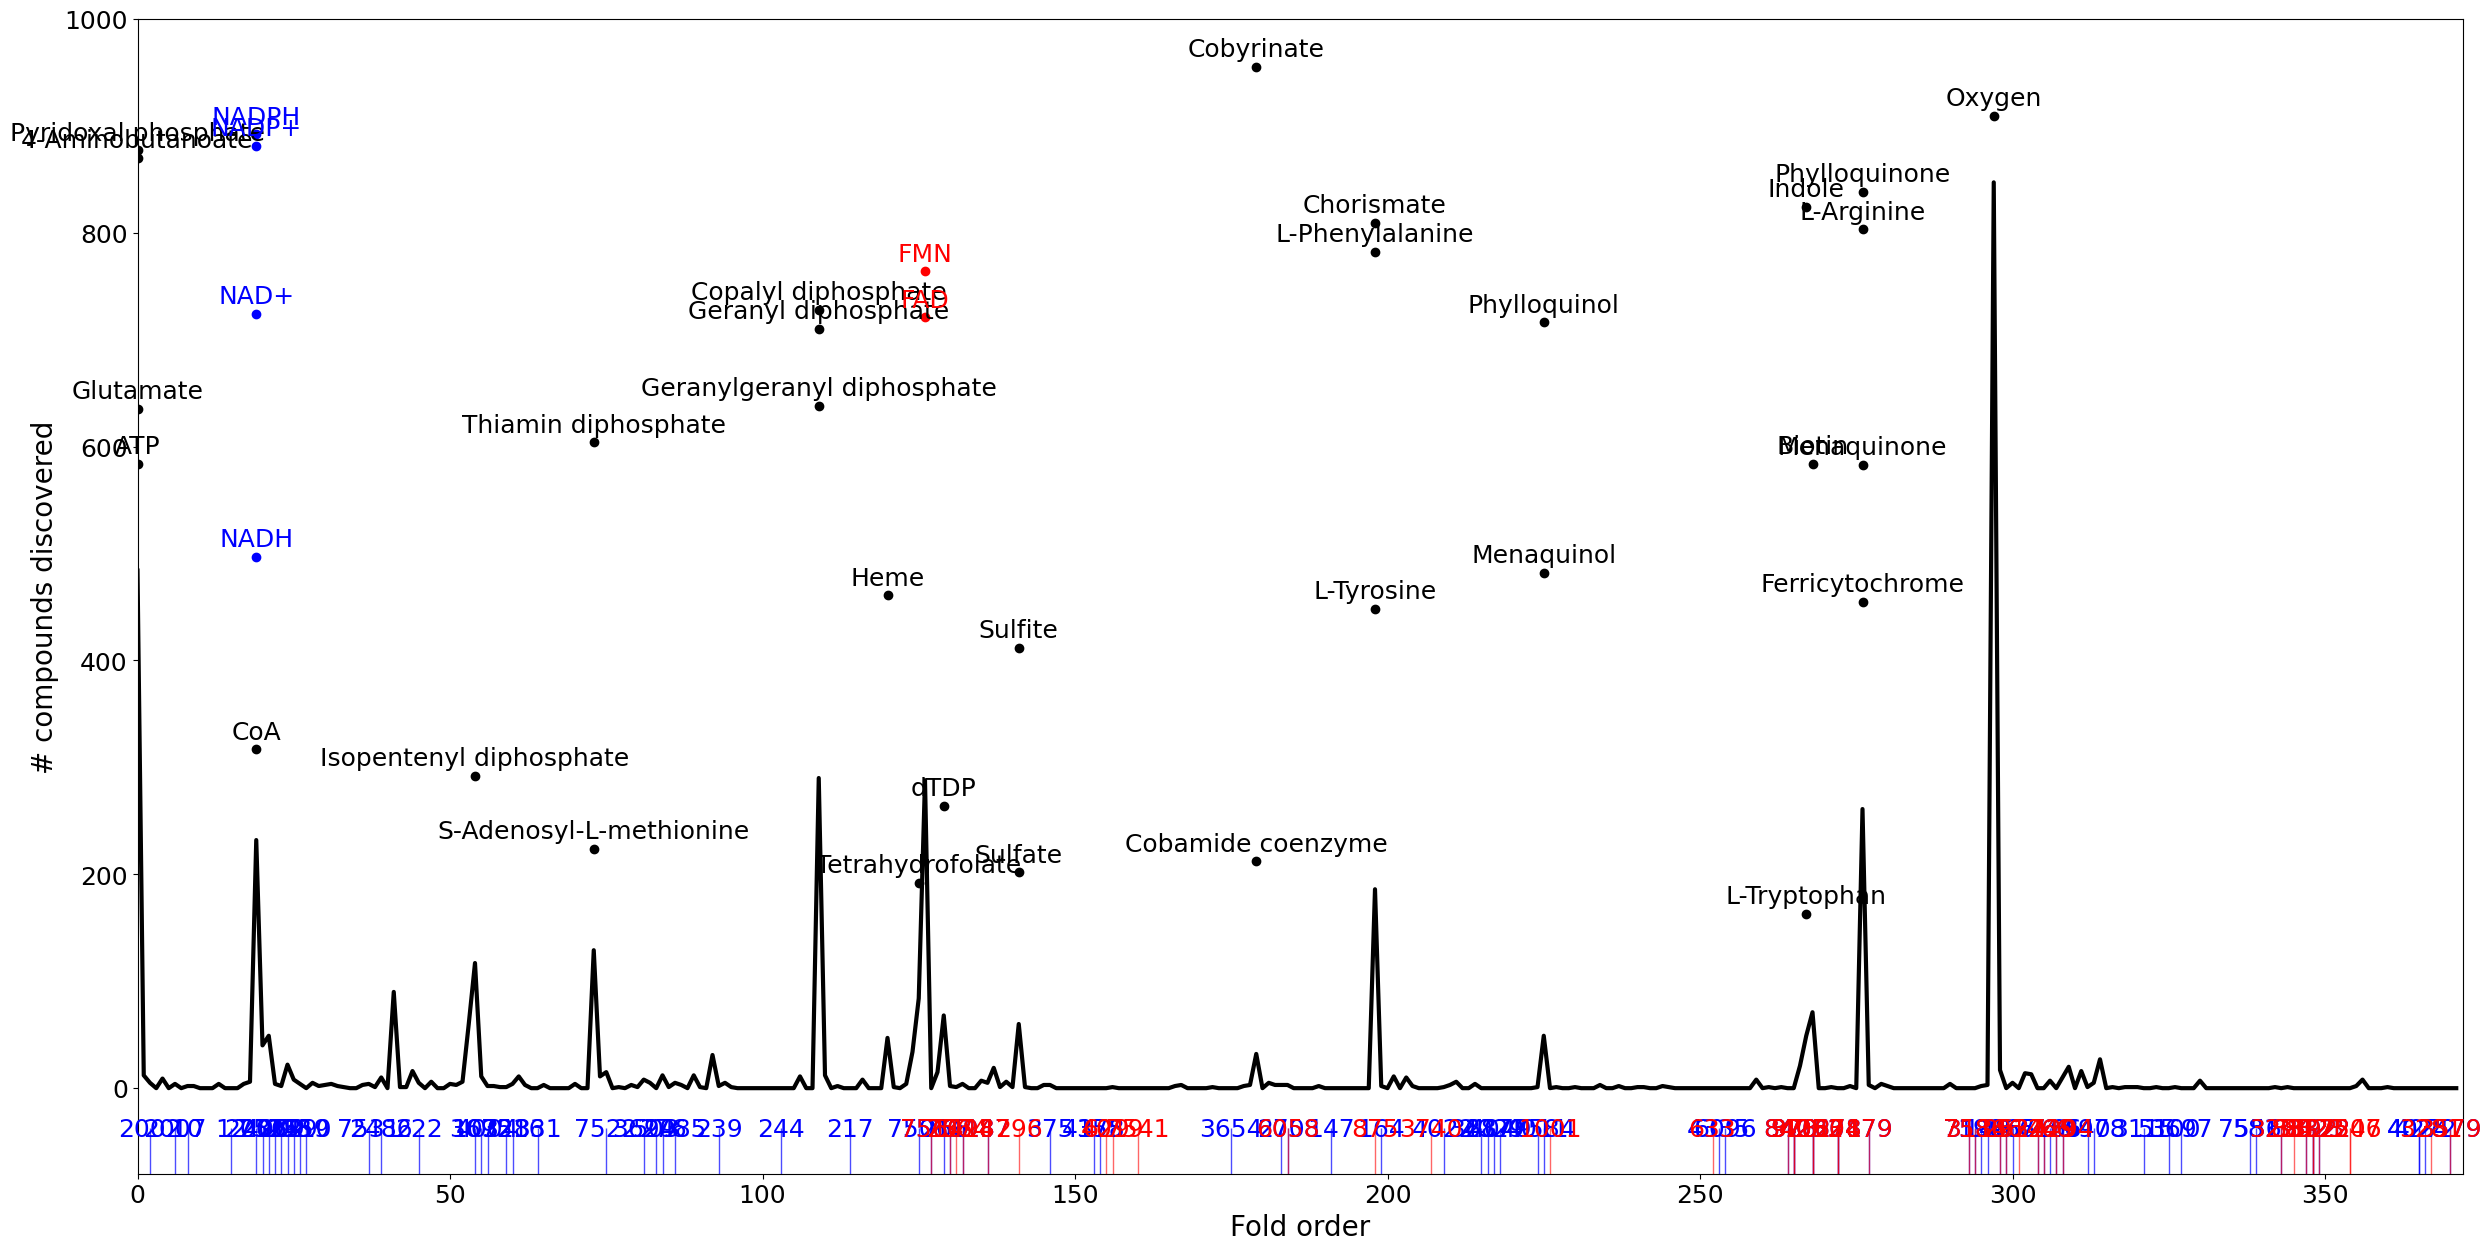

In [64]:
plt.figure(figsize=(30, 15))
plt.plot(folditer2cpdNumFull.values(), color='k', linewidth=3)

# Add annotations for cpds
for key, value in cpd2iter.items():
    position = random.randint(folditer2cpdNumFull[value], 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='k', fontsize='18')
    plt.scatter(value, position-5, color='k')
for key, value in cpd2iter_NAD.items():
    position = random.randint(folditer2cpdNumFull[value], 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='blue', fontsize='18')
    plt.scatter(value, position-5, color='blue')
for key, value in cpd2iter_FAD.items():
    position = random.randint(folditer2cpdNumFull[value], 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='red', fontsize='18')
    plt.scatter(value, position-5, color='red')

# Create a rugplot
sns.rugplot(list(NAD_ETU_iters.values()), height=0.04, color='blue', alpha = 0.7) 
sns.rugplot(list(FAD_ETU_iters.values()), height=0.04, color='red', alpha = 0.6)
# Add annotations for folds on rugplot
for key, value in NAD_ETU_iters.items():
    position = -50
    plt.text(value, position, key, ha='center', va='bottom', color='blue', fontsize='18')
for key, value in FAD_ETU_iters.items():
    position = -50
    plt.text(value, position, key, ha='center', va='bottom', color='red', fontsize='18')
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-80, 1000])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
plt.xlabel('Fold order', fontsize='20')
plt.ylabel('# compounds discovered', fontsize='20')
plt.yticks(fontsize='18')

# plt.savefig('folditer_cpds_annotated_redox_preATP.svg', dpi=300, bbox_inches='tight')
plt.show()

In [65]:
result.folds_folditer['2003']

5

In [67]:
folditer2rns = {}
for rn, folditer in result.rns_folditer.items():
    if folditer not in folditer2rns.keys():
        folditer2rns[folditer] = [rn]
    else:
        folditer2rns[folditer].append(rn)
print(len(folditer2rns))

294


In [69]:
len(folditer2rns[5])

48

In [70]:
my_cpds = []
for rn in folditer2rns[5]:
    my_cpds.extend(rn2cpds[rn])

In [71]:
for c in set(my_cpds):
    print(my_cpds.count(c), c, cpd2name[c])

3 C00979 O-Acetyl-L-serine
1 C00092 D-Glucose 6-phosphate
3 C00354 D-Fructose 1,6-bisphosphate
2 C00204 2-Dehydro-3-deoxy-D-gluconate
2 C02291 L-Cystathionine
2 C00002 ATP
2 C00212 Adenosine
1 C05692 Se-Adenosyl-L-selenohomocysteine
3 C05345 beta-D-Fructose 6-phosphate
1 C00740 D-Serine
3 C00033 Acetate
1 C00221 beta-D-Glucose
2 Z00055 Calcium
4 C00283 Hydrogen sulfide
1 C06393 2,3-Diaminopropanoate
1 C00031 D-Glucose
15 C00001 H2O
9 C00065 L-Serine
2 C00188 L-Threonine
4 C05167 alpha-Amino acid
6 Z00063 Generic FeS
1 C00542 Cystathionine
4 C11511 threo-3-Hydroxy-L-aspartate
28 Z00035 PLP
1 C01528 Hydrogen selenide
3 C00097 L-Cysteine
1 C00329 D-Glucosamine
4 C00009 Orthophosphate
1 C21559 N-[(2S)-2-Amino-2-carboxyethyl]-L-glutamate
2 C02218 Dehydroalanine
4 C00036 Oxaloacetate
4 C00155 L-Homocysteine
4 C00022 Pyruvate
1 C05699 L-Selenocystathionine
4 Z00069 Divalent Metal (M2)
1 C00025 L-Glutamate
1 C01172 beta-D-Glucose 6-phosphate
2 C00051 Glutathione
1 C01234 1-Aminocyclopropane-1-

In [72]:
result.cpds_folditer['Z00032']

1

In [73]:
for rn, cpds in rn2cpds.items():
    if 'Z00032' in cpds:
        print(rn, result.rns_folditer.get(rn, 'N/A'))

R00018_v1 53
R00019_v1 366
R00028_v1 15
R00227_v1 64
R00229_v1 19
R00272_v1 75
R00291_v1 126
R00293_v1 126
R00409_v1 2
R00418_v1 126
R00505_v1 276
R00609_v1 146
R00610_v1 297
R00614_v1 20
R00635_v1 297
R00635_v2 297
R00671_v1 55
R00750_v1 54
R00750_v2 54
R00801_v1 8
R00802_v1 8
R00839_v2 2
R00874_v1 24
R00888_v1 19
R00889_v1 19
R00893_v1 297
R00910_v1 54
R00912_v1 276
R00920_v1 19
R00944_v1 125
R00946_v2 276
R01078_v1 268
R01101_v1 19
R01103_v1 19
R01104_v1 19
R01164_v1 92
R01175_v1 276
R01178_v1 N/A
R01194_v1 24
R01329_v1 19
R01342_v1 126
R01384_v1 126
R01385_v1 126
R01447_v1 1
R01473_v1 126
R01482_v1 20
R01701_v1 276
R01702_v1 276
R01709_v1 297
R01709_v2 297
R01715_v1 198
R01751_v1 26
R01881_v1 295
R01919_v1 53
R01982_v1 N/A
R01983_v1 20
R01991_v1 92
R02025_v1 276
R02125_v1 297
R02125_v2 297
R02218_v1 N/A
R02222_v1 313
R02351_v1 N/A
R02426_v1 126
R02480_v1 N/A
R02512_v1 276
R02560_v1 276
R02657_v1 297
R02657_v2 297
R02661_v1 268
R02685_v1 39
R02725_v1 N/A
R02726_v1 N/A
R02825_v1 54
R

In [74]:
for c in rn2cpds['R12588_v1']:
    print(c, cpd2name[c], result.cpds_folditer[c])

C00294 Inosine 0
C00001 H2O 0
Z00032 NAD/NADP 1
C03431 S-Inosyl-L-homocysteine 0
C00155 L-Homocysteine 0


In [75]:
result.cpds_folditer['C00857']

0

In [76]:
for rn in ['R01447_v1', 'R12588_v1', 'RZ_328']:
    print(rn, result.rns_folditer.get(rn, 'N/A'), rn2eqn[rn], rn2rules.get(rn, 'N/A'), rn2rev[rn])

R01447_v1 1 C00149 + C00022 + Z00032 => C00186 + C00036 + Z00032 N/A True
R12588_v1 1 C00294 + C00155 + Z00032 => C03431 + C00001 + Z00032 N/A True
RZ_328 1 C00857 => Z00032 N/A False


In [77]:
cpd2name['C00857'], cpd2name['C00004']

('Deamino-NAD+', 'NADH')

In [78]:
cpd2fo_aveNONE = csv2dict('../data/assets/cpd2fo_aveNONE.csv')

In [79]:
cpd2fo_aveNONE['C00002']

[107.511, 3.0119560089748956]

In [80]:
cpd2fo_aveNONE['C00004']

[107.511, 3.0119560089748956]

In [81]:
cpd2fo_aveNONE['Z00032']

[107.511, 3.0119560089748956]

In [82]:
cpd2fo_aveNONE['C00857']

[107.511, 3.0119560089748956]

In [83]:
vanilla_70 = csv2dict('../data/assets/vanilla_cpd2iter_70seed.csv')
vanilla_80 = csv2dict('../data/assets/vanilla_withAA.csv')

In [84]:
vanilla_70['C00857'], vanilla_70['Z00032'], vanilla_70['C00003'], vanilla_70['C00004'], vanilla_70['C00006'], vanilla_70['C00005']

(21, 22, 22, 23, 23, 24)

In [85]:
vanilla_80['C00857'], vanilla_80['Z00032'], vanilla_80['C00003'], vanilla_80['C00004'], vanilla_80['C00006'], vanilla_80['C00005']

(20, 21, 21, 22, 22, 23)

In [86]:
# check peroxide

In [87]:
vanilla_70['C00007'], vanilla_70['C00027']

(64, 65)

In [88]:
vanilla_80['C00007'], vanilla_80['C00027']

(49, 42)

In [89]:
result.cpds_folditer['C00007'], result.cpds_folditer['C00027']

(297, 297)

In [90]:
# C00003 NAD+
# C00004 NADH
# C00006 NADP+
# C00005 NADPH

In [91]:
# folditer=19 is NAD discovery

result.folds_folditer['2005']  # HUP

19

In [92]:
rn2rules['R00189'], rn2rules['R00257']

({frozenset({'2005'})}, {frozenset({'2005', '246'})})

In [93]:
for rn in folditer2rns[19]:
    cpds = rn2cpds[rn]
    if 'Z00032' in cpds:
        print(rn, rn2eqn[rn], rn2rev[rn])

R00920_v1 C00008 + C00009 + C00100 + Z00032 => C00002 + C00163 + C00010 + Z00032 True
R05549_v1 C00124 + C05402 + Z00032 + Z00030 => C05404 + C00001 + Z00032 + Z00030 True
R00888_v1 C00096 + Z00032 => C01222 + C00001 + Z00032 False
RZ_320 C20482 => Z00032 False
RZ_323 C20483 => Z00032 False
R01329_v1 C00159 + C00124 + Z00032 + Z00030 => C05400 + C00001 + Z00032 + Z00030 True
RZ_318 C00003 => Z00032 False
R05176_v1 C06398 + Z00032 => C06397 + Z00032 True
RZ_316 C00004 => Z00032 False
R03634_v1 C00492 + C00124 + Z00032 + Z00030 => C01613 + C00001 + Z00032 + Z00030 True
R01103_v1 C00124 + C00089 + Z00032 + Z00030 => C00492 + C00001 + Z00032 + Z00030 True
RZ_330 C04899 => Z00032 False
RZ_327 C04856 => Z00032 False
R01104_v1 C00124 + C00116 + Z00032 + Z00030 => C05401 + C00001 + Z00032 + Z00030 True
RZ_317 C00005 => Z00032 False
R00889_v1 C02280 + Z00032 => C00096 + Z00032 True
R07672_v1 C15925 + Z00032 => C00096 + Z00032 True
R02926_v1 C00794 + C00124 + Z00032 + Z00030 => C05399 + C00001 +

### fix rn2cpds, rn2reac, rn2prod by removing stoichiometry

In [94]:
# rn2reac = {}
# rn2prod = {}

# for rn, eqn in rn2eqn.items():
#     reacs = eqn.split(' => ')[0].split(' + ')
#     prods = eqn.split(' => ')[1].split(' + ')
    
#     new_reacs = [c[-6:] for c in reacs]
#     new_prods = [c[-6:] for c in prods]
#     rn2reac[rn] = new_reacs
#     rn2prod[rn] = new_prods

In [95]:
# dict2csv(rn2reac, '../data/assets/rn2reac.csv')
# dict2csv(rn2prod, '../data/assets/rn2prod.csv')

In [96]:
# rn2cpds_new = {}

# for rn, cpds in rn2cpds_SI.items():    
#     new_cpds = [c[-6:] for c in cpds]
#     rn2cpds_new[rn] = new_cpds
    
# rn2cpds_new

In [97]:
# dict2csv(rn2cpds_new, '../data/assets/rn2cpds_SI.csv')

### back to analysis

In [101]:
rn2reac = csv2dict('../data/assets/rn2reac.csv')
rn2prod = csv2dict('../data/assets/rn2reac.csv')

In [102]:
result.cpds_folditer['C00857'], result.cpds_folditer['Z00032']

(0, 1)

In [103]:
for rn, eqn in rn2eqn.items():
    if rn.startswith('RZ'):        
        zpd = rn2prod[rn]
        cpd = rn2reac[rn]
        
        if len(zpd) == 1 and len(cpd) == 1:  # simple 1to1 conversion
            if result.cpds_folditer.get(zpd[0], 999) < result.cpds_folditer.get(cpd[0], -1):  # zpd before cpd
                print(rn, eqn, result.rns_folditer.get(rn, 'N/A'))
                print("     ", cpd[0], cpd2name[cpd[0]], result.cpds_folditer.get(cpd[0], -1))
                print("     ", zpd[0], cpd2name[zpd[0]], result.cpds_folditer.get(zpd[0], 999))
        else:  # conversion with multiple cpds
            print('**************')
            print(rn, eqn, result.rns_folditer.get(rn, 'N/A'))
            for c in cpd:
                print("     ", c, cpd2name[c], result.cpds_folditer.get(c, -1))
            for c in zpd:
                print("     ", c, cpd2name[c], result.cpds_folditer.get(c, 999))
            print('**************')

**************
RZ_116 Z00002 + C00017 => Z00016 276
      Z00002 4Fe4S 0
      C00017 Protein 276
      Z00002 4Fe4S 0
      C00017 Protein 276
**************
**************
RZ_133 Z00017 + C00017 => Z00018 276
      Z00017 Flavin 126
      C00017 Protein 276
      Z00017 Flavin 126
      C00017 Protein 276
**************
**************
RZ_138 Z00017 + C00017 => Z00019 276
      Z00017 Flavin 126
      C00017 Protein 276
      Z00017 Flavin 126
      C00017 Protein 276
**************
**************
RZ_144 C00283 + Z00015 => Z00063 1
      C00283 Hydrogen sulfide 0
      Z00015 Iron 0
      C00283 Hydrogen sulfide 0
      Z00015 Iron 0
**************
**************
RZ_3 C00283 + Z00015 => Z00001 1
      C00283 Hydrogen sulfide 0
      Z00015 Iron 0
      C00283 Hydrogen sulfide 0
      Z00015 Iron 0
**************
**************
RZ_478 C00019 + C00037 + C00017 => Z00052 276
      C00019 S-Adenosyl-L-methionine 73
      C00037 Glycine 0
      C00017 Protein 276
      C00019 S-Adenosyl-L-

In [104]:
# check why above happens for each Z compound

for rn, prods in rn2prod.items():
    if rn.startswith('RZ'):
        if 'Z00050' in prods:
            if result.rns_folditer.get(rn, 'n/a') != 'n/a':
                print(rn, rn2eqn[rn], result.rns_folditer.get(rn, 'n/a'))
                for c in rn2cpds[rn]:
                    print("     ", c, cpd2name[c], result.cpds_folditer.get(c, 'n/a'))

In [105]:
result.cpds_folditer['C00153'], result.cpds_folditer['C00455']

(0, 0)

In [106]:
cpd2name['C00153'], cpd2name['C00455']

('Nicotinamide', 'Nicotinamide D-ribonucleotide')

In [107]:
for rn, cpds in rn2cpds.items():
    if rn.startswith('RZ'):
        if 'Z00032' in cpds:
            print(rn, cpds)
            for c in cpds:
                print('   ', c, cpd2name[c])

RZ_316 ['Z00032', 'C00004']
    Z00032 NAD/NADP
    C00004 NADH
RZ_317 ['Z00032', 'C00005']
    Z00032 NAD/NADP
    C00005 NADPH
RZ_318 ['Z00032', 'C00003']
    Z00032 NAD/NADP
    C00003 NAD+
RZ_319 ['C00006', 'Z00032']
    C00006 NADP+
    Z00032 NAD/NADP
RZ_320 ['C20482', 'Z00032']
    C20482 (6R)-6beta-Hydroxy-1,4,5,6-tetrahydronicotinamide-adenine dinucleotide
    Z00032 NAD/NADP
RZ_321 ['Z00032', 'C21759']
    Z00032 NAD/NADP
    C21759 Isonicotinoyl-NAD adduct
RZ_322 ['Z00032', 'C21423']
    Z00032 NAD/NADP
    C21423 1,2-Dihydro-beta-NAD
RZ_323 ['Z00032', 'C20483']
    Z00032 NAD/NADP
    C20483 (6R)-6beta-Hydroxy-1,4,5,6-tetrahydronicotinamide-adenine dinucleotide phosphate
RZ_324 ['Z00032', 'C21424']
    Z00032 NAD/NADP
    C21424 1,6-Dihydro-beta-NAD
RZ_325 ['C20745', 'Z00032']
    C20745 alpha-NADPH
    Z00032 NAD/NADP
RZ_326 ['C21760', 'Z00032']
    C21760 Isonicotinoyl-NADP adduct
    Z00032 NAD/NADP
RZ_327 ['Z00032', 'C04856']
    Z00032 NAD/NADP
    C04856 (6S)-6beta-Hy

# ATP grasp plot

In [109]:
GATP_rns = {'R00200_gATP_v1',
    'R00200_gATP_v2',
    'R00430_gGTP_v1',
    'R00430_gGTP_v2',
    'R01523_gATP_v1',
    'R04144_gATP_v1',
    'R04208_gATP',
    'R04463_gATP',
    'R04591_gATP_v1',
    'R06836_gATP',
    'R06974_gATP',
    'R06975_gATP_v1'}

cs = set()
for rn in GATP_rns:
    for c in rn2cpds[rn]:
        cs.add(c)
for c in cs:
    print(c, cpd2name[c])

C03373 Aminoimidazole ribotide
C00013 Diphosphate
Z00026 K (Potassium)
C00119 5-Phospho-alpha-D-ribose 1-diphosphate
C01182 D-Ribulose 1,5-bisphosphate
C03838 5'-Phosphoribosylglycinamide
C04823 1-(5'-Phosphoribosyl)-5-amino-4-(N-succinocarboxamide)-imidazole
C00001 H2O
C00009 Orthophosphate
C00064 L-Glutamine
C00049 L-Aspartate
C04751 1-(5-Phospho-D-ribosyl)-5-amino-4-imidazolecarboxylate
C00022 Pyruvate
C00058 Formate
C00025 L-Glutamate
Z00069 Divalent Metal (M2)
Z00030 Mn
C03090 5-Phosphoribosylamine
C04376 5'-Phosphoribosyl-N-formylglycinamide
C04734 1-(5'-Phosphoribosyl)-5-formamido-4-imidazolecarboxamide
C00199 D-Ribulose 5-phosphate
C04677 1-(5'-Phosphoribosyl)-5-amino-4-imidazolecarboxamide
C00074 Phosphoenolpyruvate
C01151 D-Ribose 1,5-bisphosphate
C04640 2-(Formamido)-N1-(5'-phosphoribosyl)acetamidine
Z00029 Mg
C00037 Glycine


In [110]:
for rn in GATP_rns:
    print(rn, rn2rules[rn])

R06975_gATP_v1 {frozenset({'206', '2003'})}
R04463_gATP {frozenset({'2007', '103', '304', '301'}), frozenset({'2007', '304', '301'})}
R06836_gATP {frozenset({'2004'})}
R00430_gGTP_v1 {frozenset({'1', '7518'})}
R04591_gATP_v1 {frozenset({'206', '2007'}), frozenset({'206'}), frozenset({'206', '325', '2003'})}
R00430_gGTP_v2 {frozenset({'1', '7518'})}
R00200_gATP_v1 {frozenset({'1', '7518'})}
R04144_gATP_v1 {frozenset({'325', '2003', '304', '301'}), frozenset({'206', '325', '2003'}), frozenset({'7571', '2003', '301', '206', '325', '304'})}
R00200_gATP_v2 {frozenset({'1', '7518'})}
R04208_gATP {frozenset({'325', '2003', '304', '301'}), frozenset({'304', '301'}), frozenset({'7571', '2003', '301', '206', '325', '304'})}
R06974_gATP {frozenset({'206', '325', '2003'})}
R01523_gATP_v1 {frozenset({'2004'})}


In [111]:
GATP_rns_ATPgrasp = {'R04144_gATP_v1', 'R04591_gATP_v1', 'R04208_gATP', 'R06975_gATP_v1', 'R06974_gATP'}

grasp2iter = {}
for rn in GATP_rns_ATPgrasp:
    print(rn, result.rns_folditer[rn])
    grasp2iter[rn] = result.rns_folditer[rn]

R06975_gATP_v1 1
R04144_gATP_v1 1
R04208_gATP 1
R06974_gATP 1
R04591_gATP_v1 1


In [112]:
grasp2iter.pop('R04144_gATP_v1')
grasp2iter.pop('R04208_gATP')
grasp2iter.pop('R06974_gATP')

1

In [113]:
result.cpds_folditer['C00002']

0

In [114]:
result.folds_folditer['206']

17

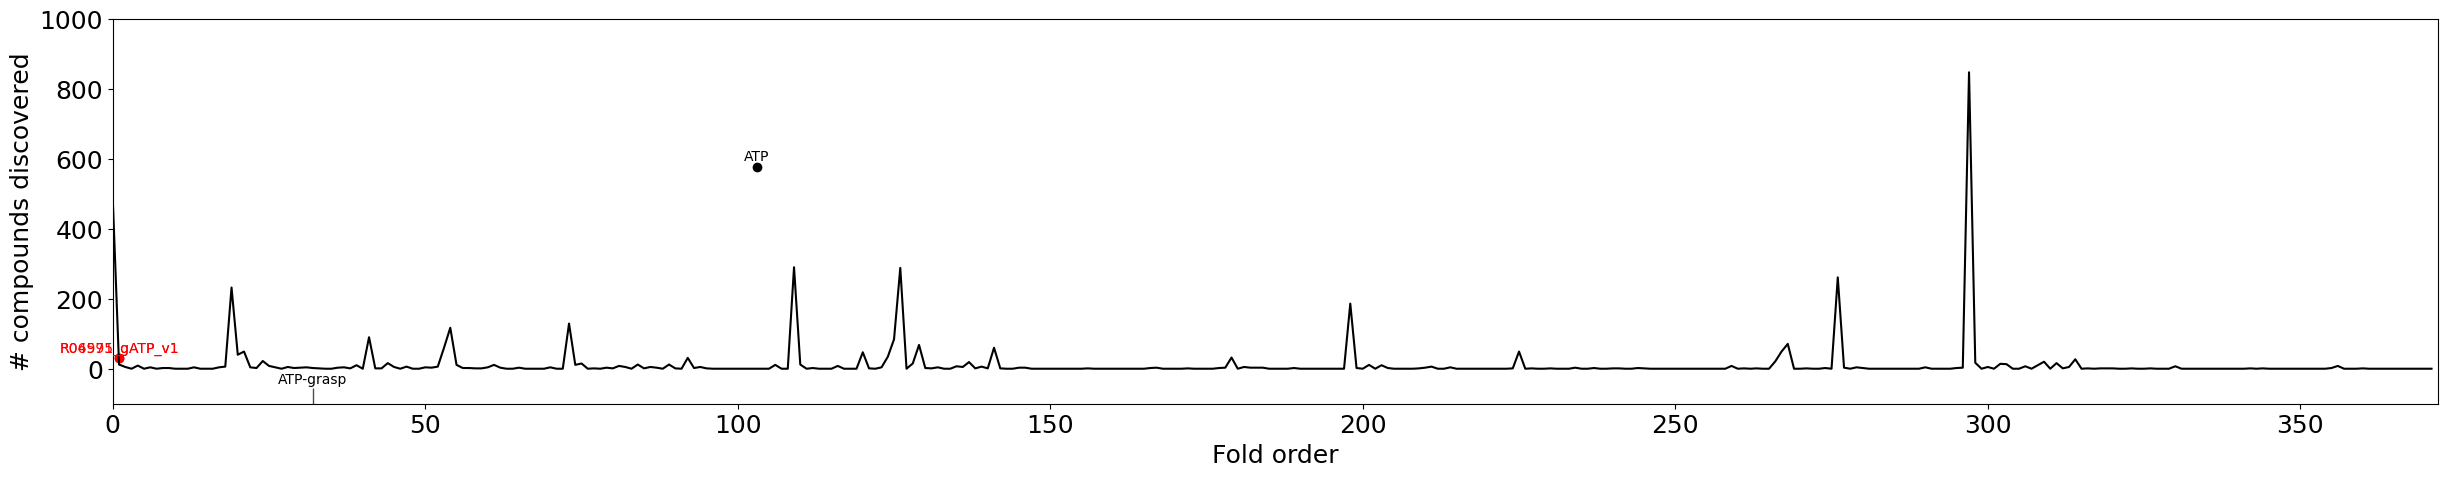

In [115]:
plt.figure(figsize=(30, 5))
plt.plot(folditer2cpdNumFull.values(), color='k')

# Add annotations for cpds
position = random.randint(100, 800)
plt.text(103, position, 'ATP', ha='center', va='bottom', color='k')
plt.scatter(103, position-10, color='k')

# Add annotations for rns
for rn, i in grasp2iter.items():
    position = 40
    plt.text(i, position, rn, ha='center', va='bottom', color='red')
    plt.scatter(i, position-10, color='red')

# Create a rugplot
sns.rugplot([32], height=0.04, color='black', alpha = 0.7) 
# Add annotations for folds
position = -50
plt.text(32, position, 'ATP-grasp', ha='center', va='bottom', color='k')
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-100, 1000])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
plt.xlabel('Fold order', fontsize='18')
plt.ylabel('# compounds discovered', fontsize='18')
plt.yticks(fontsize='18')

# plt.savefig('folditer_cpds_annotated_ATPgrasp.svg', dpi=300, bbox_inches='tight')
plt.show()

# Martina HFSP grant reactions

In [116]:
defs = ['(S)-Malate + NAD+ <=> Oxaloacetate + NADH + H+',
'Succinate + NAD+ <=> Fumarate + NADH + H+',
'Tetrahydrofolate + NAD+ <=> Dihydrofolate + NADH + H+',
'Isocitrate + NADP+ <=> 2-Oxoglutarate + CO2 + NADPH + H+',
'(S)-Dihydroorotate + NAD+ <=> Orotate + H+ + NADH',
'L-Alanine + 2-Oxoglutarate <=> Pyruvate + L-Glutamate',
'L-Glutamine + H2O <=> L-Glutamate + Ammonia',
'ATP + Deamino-NAD+ + L-Glutamine + H2O <=> AMP + Diphosphate + NAD+ + L-Glutamate']

In [117]:
my_rns = ['R00396', 'R07168', 'R00134', 'R07399']

In [118]:
for rn, d in rn2def.items():
    if d in defs:
        print(rn, d)
        my_rns.append(rn)

R00256 L-Glutamine + H2O <=> L-Glutamate + Ammonia
R00257 ATP + Deamino-NAD+ + L-Glutamine + H2O <=> AMP + Diphosphate + NAD+ + L-Glutamate
R00258 L-Alanine + 2-Oxoglutarate <=> Pyruvate + L-Glutamate
R00267 Isocitrate + NADP+ <=> 2-Oxoglutarate + CO2 + NADPH + H+
R00342 (S)-Malate + NAD+ <=> Oxaloacetate + NADH + H+
R00402 Succinate + NAD+ <=> Fumarate + NADH + H+
R00936 Tetrahydrofolate + NAD+ <=> Dihydrofolate + NADH + H+
R01869 (S)-Dihydroorotate + NAD+ <=> Orotate + H+ + NADH


In [119]:
my_rn2def = {}
my_rn2rules = {}

for rn in my_rns:
    my_rn2def[rn] = rn2def[rn]
    my_rn2rules[rn] = rn2rules[rn]

In [120]:
data = []
for rn,d in my_rn2def.items():
    data.append({
        'rid': rn,
        'def': d,
        'rules': my_rn2rules[rn]
    })
    
df = pd.DataFrame(data)
df

,rid,def,rules
0,R00396,L-Alanine + NAD+ + H2O <=> Pyruvate + Ammonia ...,"{(3692, 2003), (2003)}"
1,R07168,"5-Methyltetrahydrofolate + NAD+ <=> 5,10-Methy...",{(2002)}
2,R00134,Formate + NADP+ <=> CO2 + NADPH + H+,"{(5100, 1001, 187, 1, 221, 2003, 633, 205)}"
3,R07399,Acetyl-CoA + Pyruvate + H2O <=> (R)-2-Methylma...,"{(103, 330, 2002)}"
4,R00256,L-Glutamine + H2O <=> L-Glutamate + Ammonia,"{(7507, 7546), (2007, 2003, 206, 2487, 101, 75..."
5,R00257,ATP + Deamino-NAD+ + L-Glutamine + H2O <=> AMP...,"{(2005, 246)}"
6,R00258,L-Alanine + 2-Oxoglutarate <=> Pyruvate + L-Gl...,"{(3016, 7577)}"
7,R00267,Isocitrate + NADP+ <=> 2-Oxoglutarate + CO2 + ...,{(7510)}
8,R00342,(S)-Malate + NAD+ <=> Oxaloacetate + NADH + H+,"{(279, 2003)}"
9,R00402,Succinate + NAD+ <=> Fumarate + NADH + H+,"{(604, 187, 221, 2003, 278, 205)}"


In [121]:
df = df.sort_values(by='rid')
df = df.reset_index()
df = df.drop('index', axis=1)
df

# df.to_csv('rid_def_rules_02Sep2024.csv')

,rid,def,rules
0,R00134,Formate + NADP+ <=> CO2 + NADPH + H+,"{(5100, 1001, 187, 1, 221, 2003, 633, 205)}"
1,R00256,L-Glutamine + H2O <=> L-Glutamate + Ammonia,"{(7507, 7546), (2007, 2003, 206, 2487, 101, 75..."
2,R00257,ATP + Deamino-NAD+ + L-Glutamine + H2O <=> AMP...,"{(2005, 246)}"
3,R00258,L-Alanine + 2-Oxoglutarate <=> Pyruvate + L-Gl...,"{(3016, 7577)}"
4,R00267,Isocitrate + NADP+ <=> 2-Oxoglutarate + CO2 + ...,{(7510)}
5,R00342,(S)-Malate + NAD+ <=> Oxaloacetate + NADH + H+,"{(279, 2003)}"
6,R00396,L-Alanine + NAD+ + H2O <=> Pyruvate + Ammonia ...,"{(3692, 2003), (2003)}"
7,R00402,Succinate + NAD+ <=> Fumarate + NADH + H+,"{(604, 187, 221, 2003, 278, 205)}"
8,R00936,Tetrahydrofolate + NAD+ <=> Dihydrofolate + NA...,"{(7501), (266, 7501)}"
9,R01869,(S)-Dihydroorotate + NAD+ <=> Orotate + H+ + NADH,{(2002)}


# HFSP plot 09Sep2024

In [ ]:
# Starts from ATP pre-expansion
# Shows the major cofactor emergence points (like NAD)

In [127]:
folditer2rns

{1: ['RZ_390',
  'R11101_v1',
  'R03801',
  'R12221',
  'RZ_499',
  'R00263',
  'R05781',
  'R03693',
  'RZ_506',
  'R01052',
  'R00320',
  'RZ_424',
  'R01200',
  'R10469_v2',
  'R04399',
  'R03897',
  'R11098_v1',
  'RZ_498',
  'R01081',
  'R05839',
  'RZ_493',
  'R01437_v1',
  'R00476_v1',
  'R04177',
  'R06837',
  'RZ_140',
  'R01336',
  'RZ_251',
  'RZ_113',
  'R06836_gATP',
  'R11100_v2',
  'R03127',
  'R00141',
  'R01147',
  'R05142',
  'R11099_v1',
  'RZ_340',
  'R04012',
  'R12588_v1',
  'R04933',
  'RZ_27',
  'R00347_v4',
  'R00430_gGTP_v2',
  'FeS_C22151_syn',
  'R01580',
  'RZ_5',
  'R00430_gGTP_v1',
  'RZ_139',
  'R00347_v3',
  'R00363',
  'R00482',
  'R00576_v1',
  'R00347_v2',
  'RZ_106',
  'RZ_258',
  'R01393',
  'R01573',
  'R09795',
  'R00917',
  'R00200_gATP_v2',
  'R04943',
  'R01576',
  'R00400_v1',
  'RZ_3',
  'R01652_v1',
  'R00916',
  'R05141',
  'RZ_492',
  'R04446',
  'RZ_423',
  'R01266',
  'R02546',
  'R10469_v1',
  'R01523_v2',
  'R10809',
  'R11098_v2',
  

In [146]:
# Annotates every time the Rossmann fold is used again in the rug plot

rule2fo = {}
for key, value in result.rules_folditer.items():
    if key[1] not in rule2fo.keys():
        rule2fo[key[1]] = [value]
    else:
        rule2fo[key[1]].append(value)

folditer2rules = {}
for key , values in rule2fo.items():
    for value in values:
        if value not in folditer2rules.keys():
            folditer2rules[value] = [key]
        else:
            folditer2rules[value].append(key)
        
x2usage = {x:set() for x in result.folds_folditer.keys()}  # empty dict
x2usage.pop('fold_independent')
x2usage.pop('spontaneous')

for i, rules in folditer2rules.items():
    for rule in rules:
        for x in rule:
            if x in x2usage: # ignore 'fold_independent' and 'spontaneous'
                x2usage[x].add(i)  # don't record multiple usage within one fold_iter
x2usage = {x:sorted(list(s)) for x,s in x2usage.items()}

x2usage['2003']

[5,
 6,
 7,
 9,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 37,
 38,
 39,
 41,
 43,
 44,
 45,
 47,
 52,
 53,
 54,
 55,
 59,
 60,
 62,
 64,
 70,
 71,
 72,
 73,
 74,
 75,
 79,
 80,
 81,
 84,
 86,
 87,
 89,
 92,
 103,
 105,
 109,
 110,
 111,
 124,
 125,
 126,
 129,
 131,
 132,
 135,
 136,
 137,
 141,
 146,
 166,
 175,
 178,
 179,
 181,
 182,
 183,
 188,
 191,
 198,
 199,
 201,
 203,
 209,
 212,
 214,
 217,
 218,
 225,
 226,
 244,
 245,
 248,
 252,
 254,
 266,
 267,
 268,
 269,
 270,
 272,
 274,
 276,
 281,
 290,
 297,
 303,
 306,
 308,
 309,
 311,
 314,
 325,
 327,
 330,
 334,
 343,
 347,
 350,
 355,
 356,
 370]

In [137]:
result.folds_folditer.items()

dict_items([('fold_independent', 0), ('spontaneous', 1), ('2002', 2), ('2006', 3), ('2484', 4), ('2003', 5), ('2007', 6), ('1', 7), ('10', 8), ('304', 9), ('7527', 10), ('246', 11), ('805', 12), ('221', 13), ('7525', 14), ('12', 15), ('11', 16), ('206', 17), ('2004', 18), ('2005', 19), ('236', 20), ('7524', 21), ('4002', 22), ('279', 23), ('298', 24), ('129', 25), ('7510', 26), ('159', 27), ('2011', 28), ('5', 29), ('218', 30), ('131', 31), ('7579', 32), ('2487', 33), ('210', 34), ('109', 35), ('7542', 36), ('7531', 37), ('325', 38), ('2486', 39), ('7518', 40), ('7581', 41), ('223', 42), ('301', 43), ('281', 44), ('222', 45), ('7504', 46), ('213', 47), ('7515', 48), ('7572', 49), ('212', 50), ('7512', 51), ('7577', 52), ('3016', 53), ('103', 54), ('3692', 55), ('4004', 56), ('4021', 57), ('247', 58), ('328', 59), ('7516', 60), ('208', 61), ('286', 62), ('7528', 63), ('331', 64), ('65', 65), ('7573', 66), ('5104', 67), ('7517', 68), ('180', 69), ('219', 70), ('282', 71), ('70', 72), ('3

In [141]:
near_rossmann = {'2002': 2, '2006': 3, '2484': 4, '2007': 6, '1': 7, '10': 8}

In [ ]:
# Annotates every fold that emerges before the Rossmann, and the next couple of folds

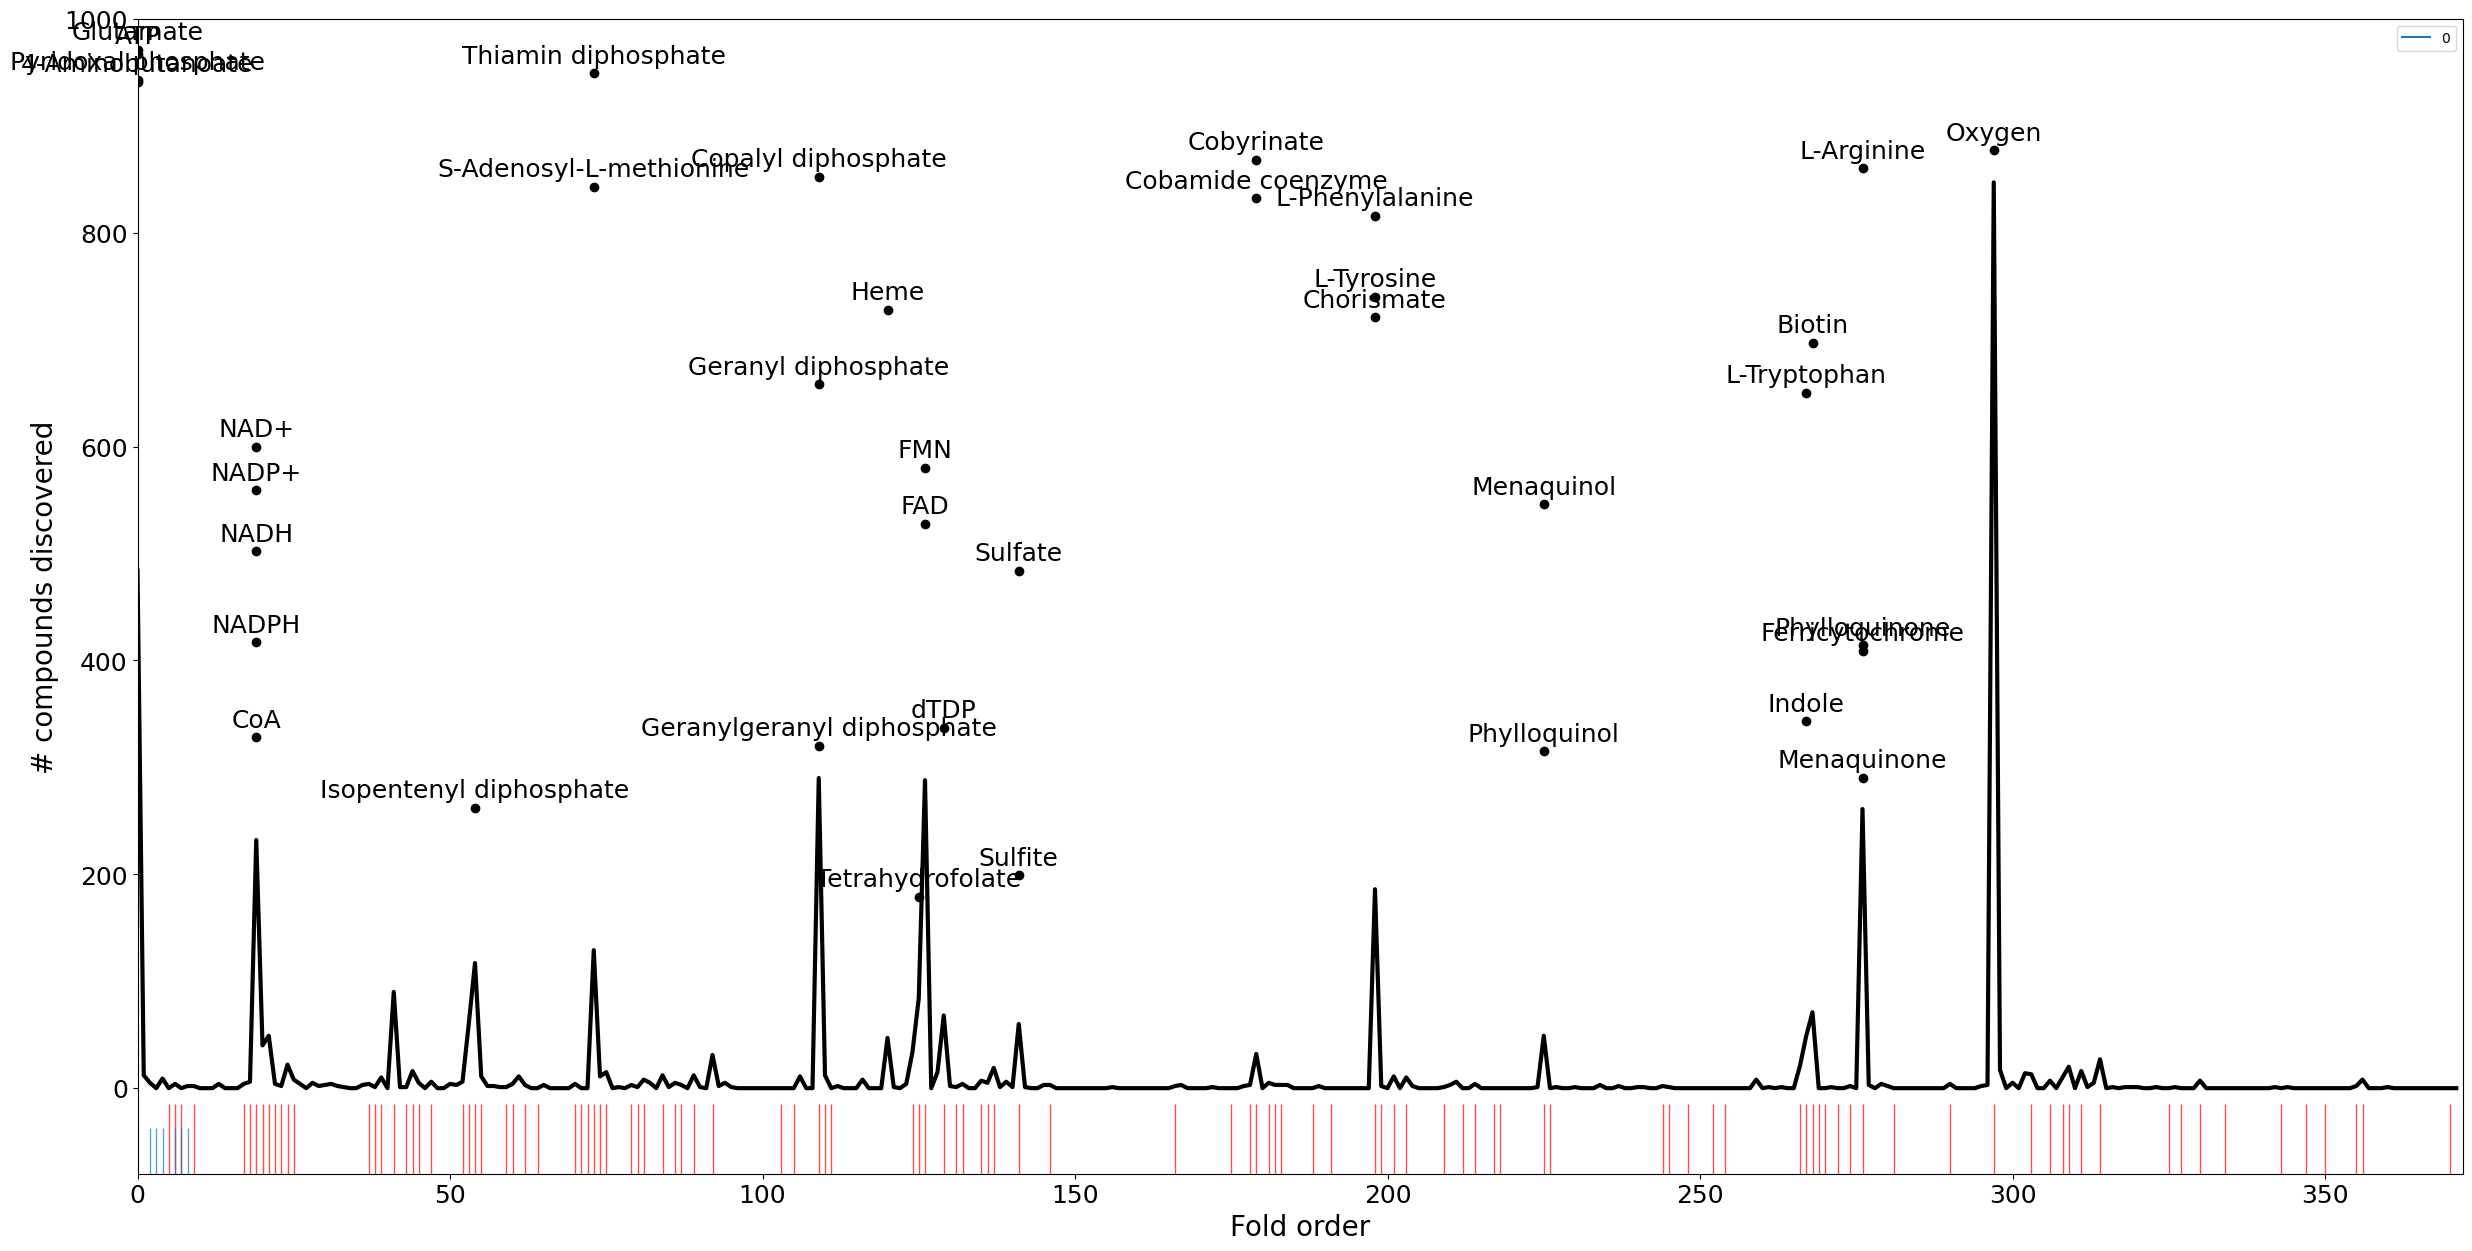

In [145]:
plt.figure(figsize=(30, 15))
plt.plot(folditer2cpdNumFull.values(), color='k', linewidth=3)

# Add annotations for cpds
for key, value in cpd2iter.items():
    position = random.randint(folditer2cpdNumFull[value], 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='k', fontsize='18')
    plt.scatter(value, position-5, color='k')
for key, value in cpd2iter_NAD.items():
    position = random.randint(folditer2cpdNumFull[value], 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='k', fontsize='18')
    plt.scatter(value, position-5, color='k')
for key, value in cpd2iter_FAD.items():
    position = random.randint(folditer2cpdNumFull[value], 1000)
    plt.text(value, position, cpd2name[key], ha='center', va='bottom', color='k', fontsize='18')
    plt.scatter(value, position-5, color='k')

# Create a rugplot
sns.rugplot(x2usage['2003'], height=0.06, color='red', alpha = 0.7) 
sns.rugplot(near_rossmann.values(), height=0.04, color='blue', alpha = 0.7)

# for key, value in near_rossmann.items():
#     position = -50
#     plt.text(value, position, key, ha='center', va='bottom', color='blue', fontsize='18')
    
plt.xlim([0, len(folditer2cpdNumFull)])
plt.ylim([-80, 1000])
plt.xticks(fontsize='18')
plt.yticks(fontsize='18')
plt.xlabel('Fold order', fontsize='20')
plt.ylabel('# compounds discovered', fontsize='20')
plt.yticks(fontsize='18')

plt.savefig('folditer_cpds_rossmann_reuse.svg', dpi=300, bbox_inches='tight')
plt.show()

In [160]:
# x2usage with reactionRules

rnRule2fo = {}
for key, value in result.rules_cumiter.items():
    if key not in rnRule2fo.keys():
        rnRule2fo[key] = [value]
    else:
        rnRule2fo[key].append(value)

cumiter2rnRules = {}
for key, values in rnRule2fo.items():
    for value in values:
        if value not in cumiter2rnRules.keys():
            cumiter2rnRules[value] = [key]
        else:
            cumiter2rnRules[value].append(key)

x2usage2 = {x:[] for x in result.folds_cumiter.keys()}  # empty dict
x2usage2.pop('fold_independent')
x2usage2.pop('spontaneous')

for i, rnRules in cumiter2rnRules.items():
    for rnRule in rnRules:
        for x in rnRule[1]:
            if x in x2usage2: # ignore 'fold_independent' and 'spontaneous'
                x2usage2[x].append((i, rnRule))
x2usage2 = {x:sorted(list(s)) for x,s in x2usage2.items()}

x2usage2['2003']

[(9, ('R00192', frozenset({'2003'}))),
 (9, ('R00195_v1', frozenset({'2003'}))),
 (9, ('R00220_v1', frozenset({'2003'}))),
 (9, ('R00220_v2', frozenset({'2003'}))),
 (9, ('R00497_v1', frozenset({'2003'}))),
 (9, ('R00497_v2', frozenset({'2003'}))),
 (9, ('R00589_v1', frozenset({'2003'}))),
 (9, ('R00590_v1', frozenset({'2003'}))),
 (9, ('R00590_v2', frozenset({'2003'}))),
 (9, ('R00765', frozenset({'2003'}))),
 (9, ('R00873', frozenset({'2003'}))),
 (9, ('R00891_v1', frozenset({'2003'}))),
 (9, ('R00897_v1', frozenset({'2003'}))),
 (9, ('R00996_v1', frozenset({'2003'}))),
 (9, ('R00996_v2', frozenset({'2003'}))),
 (9, ('R00997_v1', frozenset({'2003'}))),
 (9, ('R01289_v1', frozenset({'2003'}))),
 (9, ('R01290_v1', frozenset({'2003'}))),
 (9, ('R01544_v1', frozenset({'2003'}))),
 (9, ('R01874_v1', frozenset({'2003'}))),
 (9, ('R03601_v1', frozenset({'2003'}))),
 (9, ('R04936', frozenset({'2003'}))),
 (9, ('R04942_v1', frozenset({'2003'}))),
 (9, ('R05758_v1', frozenset({'2003'}))),
 (9,

In [174]:
result.cpds_cumiter['C00003'], cpd2name['C00003'], result.cpds_folditer['C00003'],

(29, 'NAD+', 19)

In [163]:
for i in x2usage2['2003']:
    rn = i[1][0]
    cpds = rn2cpds[rn]
    if 'C00003' in cpds:
        print(i, rn, cpds)

(30, ('R00365_v1', frozenset({'2003'}))) R00365_v1 ['C00004', 'C00037', 'Z00029', 'C00014', 'C00001', 'C00003', 'C00080', 'C00048']
(30, ('R00396_v1', frozenset({'2003'}))) R00396_v1 ['C00022', 'C00004', 'Z00029', 'C00014', 'C00001', 'C00003', 'C00080', 'C00041']
(30, ('R00519_v1', frozenset({'2003'}))) R00519_v1 ['C00004', 'C00058', 'Z00064', 'C00003', 'C00080', 'C00011', 'Z00002']
(30, ('R00704', frozenset({'2003'}))) R00704 ['C00022', 'C00004', 'C00003', 'C00080', 'C00256']
(30, ('R00717', frozenset({'2003'}))) R00717 ['C00004', 'C00160', 'C00003', 'C00080', 'C00048']
(30, ('R01088', frozenset({'2007', '2003'}))) R01088 ['C00004', 'C00014', 'C00233', 'C00001', 'C00123', 'C00003', 'C00080']
(30, ('R01388', frozenset({'2003'}))) R01388 ['C00004', 'C00258', 'C00003', 'C00080', 'C00168']
(30, ('R01429', frozenset({'2003'}))) R01429 ['C02266', 'C00004', 'C00181', 'C00003', 'C00080']
(30, ('R01434', frozenset({'2007', '2003'}))) R01434 ['C00004', 'C00141', 'C00014', 'C00001', 'C00183', 'C

In [170]:
# which rn makes NAD+ at cumiter=29?

for rnRule in cumiter2rnRules[29]:
    rn = rnRule[0]
    cpds = rn2cpds[rn]

    if 'C00003' in cpds:
        print(rnRule, cpds)

('R00137_v3', frozenset({'2005'})) ['C00013', 'Z00029', 'C00455', 'C00003', 'C00002']
('R00137_v1', frozenset({'2005'})) ['C00013', 'Z00034', 'Z00029', 'C00455', 'C00003', 'C00002']
('R00189', frozenset({'2005'})) ['C00013', 'C00020', 'C00857', 'C00014', 'C00003', 'C00002']
('R00137_v2', frozenset({'2005'})) ['C00013', 'C00455', 'Z00006', 'C00003', 'C00002']
('R00257', frozenset({'2005', '246'})) ['C00013', 'C00020', 'C00857', 'C00001', 'C00064', 'C00025', 'C00003', 'C00002']
('R00137_v4', frozenset({'2005', '221'})) ['C00013', 'Z00069', 'C00455', 'C00003', 'C00002']
('R00137_v4', frozenset({'2005'})) ['C00013', 'Z00069', 'C00455', 'C00003', 'C00002']
('R00137_v3', frozenset({'2005', '221'})) ['C00013', 'Z00029', 'C00455', 'C00003', 'C00002']
('R00137_v1', frozenset({'2005', '221'})) ['C00013', 'Z00034', 'Z00029', 'C00455', 'C00003', 'C00002']
('R00137_v2', frozenset({'2005', '221'})) ['C00013', 'C00455', 'Z00006', 'C00003', 'C00002']


In [171]:
len(cumiter2rnRules[29])

19

In [180]:
# what is rossmann doing before that?

for i in x2usage2['2003']:
    rn = i[1][0]
    cpds = rn2cpds[rn]
    if i[0] < 30:
        print(i, rn2def.get(rn[:6], 'no definition'))

(9, ('R00192', frozenset({'2003'}))) S-Adenosyl-L-homocysteine + H2O <=> Adenosine + L-Homocysteine
(9, ('R00195_v1', frozenset({'2003'}))) 2,3-Diaminopropanoate + H2O <=> Pyruvate + 2 Ammonia
(9, ('R00220_v1', frozenset({'2003'}))) L-Serine <=> Pyruvate + Ammonia
(9, ('R00220_v2', frozenset({'2003'}))) L-Serine <=> Pyruvate + Ammonia
(9, ('R00497_v1', frozenset({'2003'}))) ATP + gamma-L-Glutamyl-L-cysteine + Glycine <=> ADP + Orthophosphate + Glutathione
(9, ('R00497_v2', frozenset({'2003'}))) ATP + gamma-L-Glutamyl-L-cysteine + Glycine <=> ADP + Orthophosphate + Glutathione
(9, ('R00589_v1', frozenset({'2003'}))) L-Serine <=> D-Serine
(9, ('R00590_v1', frozenset({'2003'}))) L-Serine <=> Dehydroalanine + H2O
(9, ('R00590_v2', frozenset({'2003'}))) L-Serine <=> Dehydroalanine + H2O
(9, ('R00765', frozenset({'2003'}))) D-Glucosamine 6-phosphate + H2O <=> D-Fructose 6-phosphate + Ammonia
(9, ('R00873', frozenset({'2003'}))) D-Fructose + Ubiquinone <=> 5-Dehydro-D-fructose + Ubiquinol
(9,